# Imports:


In [ ]:
import importlib
import pickle
import time
import warnings
from collections import Counter
import torch

import os, tempfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats
from scipy.stats import ttest_rel
from scipy.signal import butter, filtfilt


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC

from data_utils import load_participant, compute_magnitudes
from data_splitting import split_within_subject, split_between_subjects
from transformations import process_split_scenarios
from statistics_analysis import analyze_statistical_significance
from outliers import compare_zscores, outlier_density_iqr, zscore_outliers
from clustering import dbscan_outliers, kmeans_outliers, plot_dbscan_results

import feature_extraction
importlib.reload(feature_extraction)

from feature_extraction import (
    extract_features_pipeline_multivariate,
    extract_multivariate_features,
    normalize_features,
    apply_pca_with_analysis,
    fisher_score,
    reliefF_optimized,
    identify_top_features,
    compare_top_features,
    get_compressed_features,
    explain_feature_selection,
    custom_smote
)
from embeddings_extractor import generate_embeddings_dataset, load_model, resample_segment

# Meta 1:

In [2]:
all_dfs = []

for pid in range(0, 15): 
    df_part = load_participant(pid) 
    if df_part is not None:
        all_dfs.append(df_part)
        print(f"Participante {pid} carregado.")
    else:
        print(f"Participante {pid} não encontrado.")

if not all_dfs:
    print("\nNenhum ficheiro encontrado.")
    print("Verifique se o caminho 'DATA_DIR' no ficheiro 'data_utils.py' está correto.")
else:
    df = pd.concat(all_dfs, ignore_index=True)
    df = compute_magnitudes(df)

    devices = {
      1: "Pulso esquerdo", 2: "Pulso direito", 3: "Peito",
      4: "Perna superior direita", 5: "Perna inferior esquerda"
    }
    sensors = {
      "acc_mag": "Aceleração (m/s²)", "gyro_mag": "Giroscópio (°/s)", "mag_mag": "Magnetómetro (µT)"
    }
    variables = list(sensors.keys())
    labels_sensores = list(sensors.values())
    


Participante 0 carregado.
Participante 1 carregado.
Participante 2 carregado.
Participante 3 carregado.
Participante 4 carregado.
Participante 5 carregado.
Participante 6 carregado.
Participante 7 carregado.
Participante 8 carregado.
Participante 9 carregado.
Participante 10 carregado.
Participante 11 carregado.
Participante 12 carregado.
Participante 13 carregado.
Participante 14 carregado.


## 3.1 - Boxplot por atividade (para todos os dispositivos)


3.1 - Boxplots por atividade (Aceleração, Giroscópio e Magnetómetro)


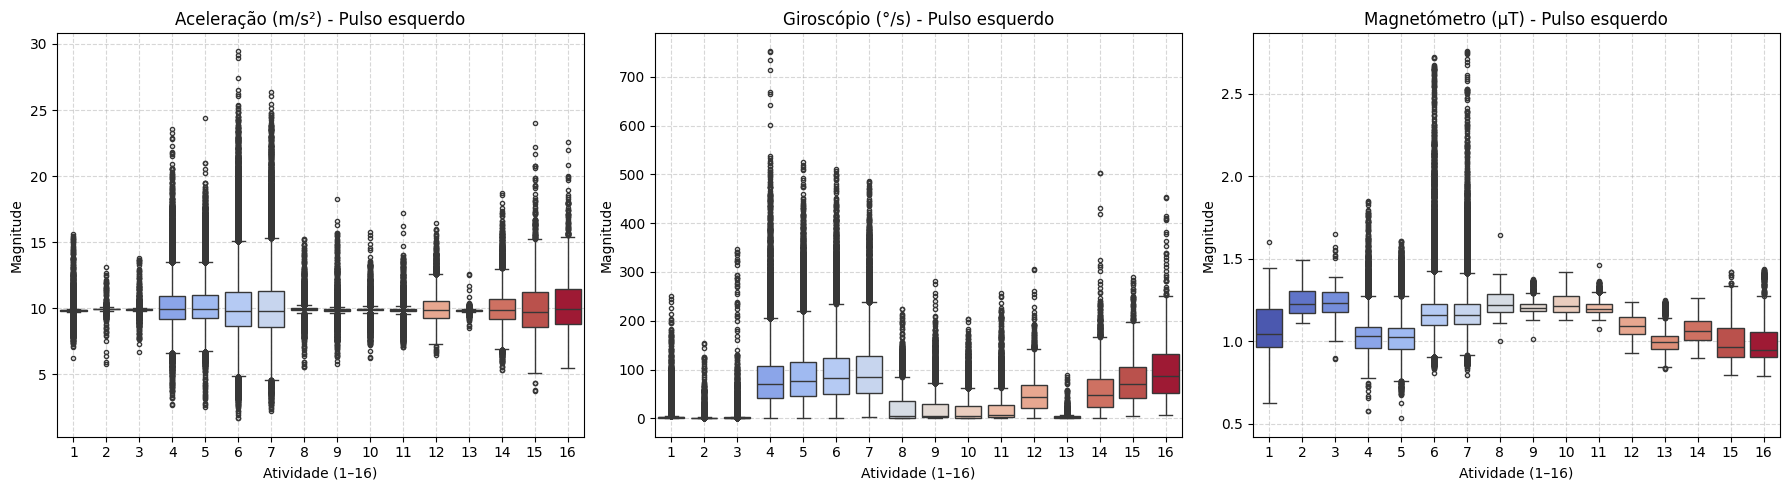

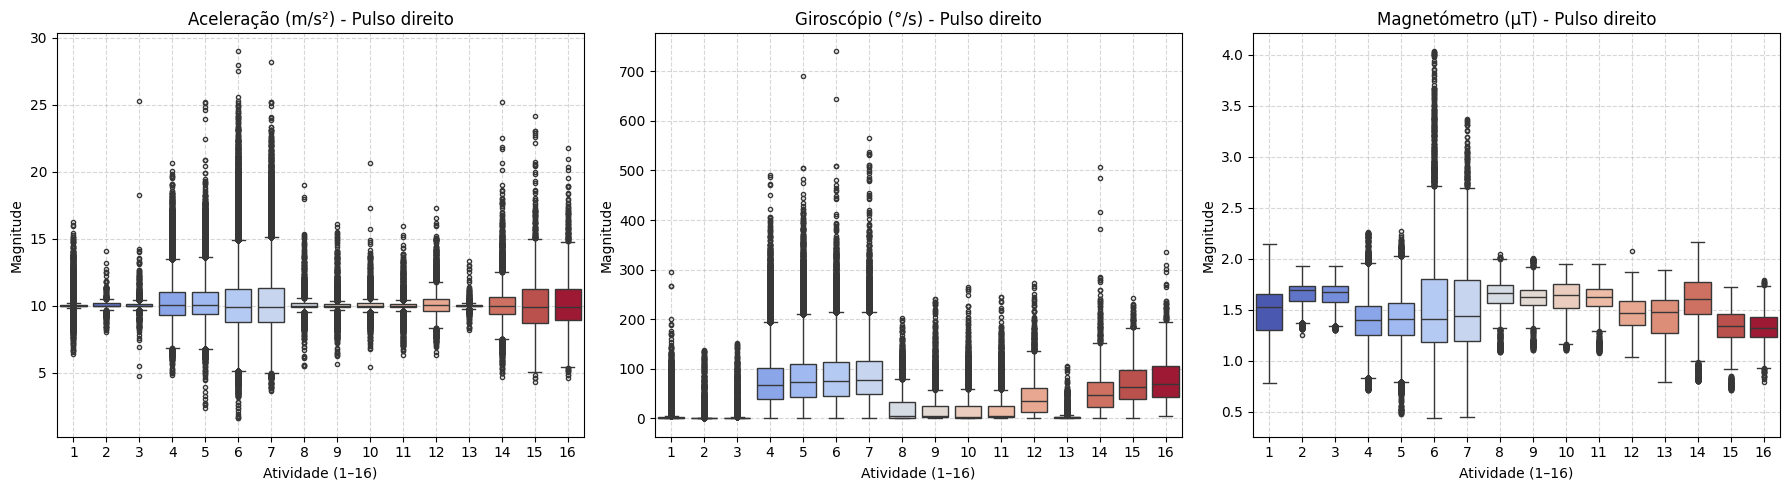

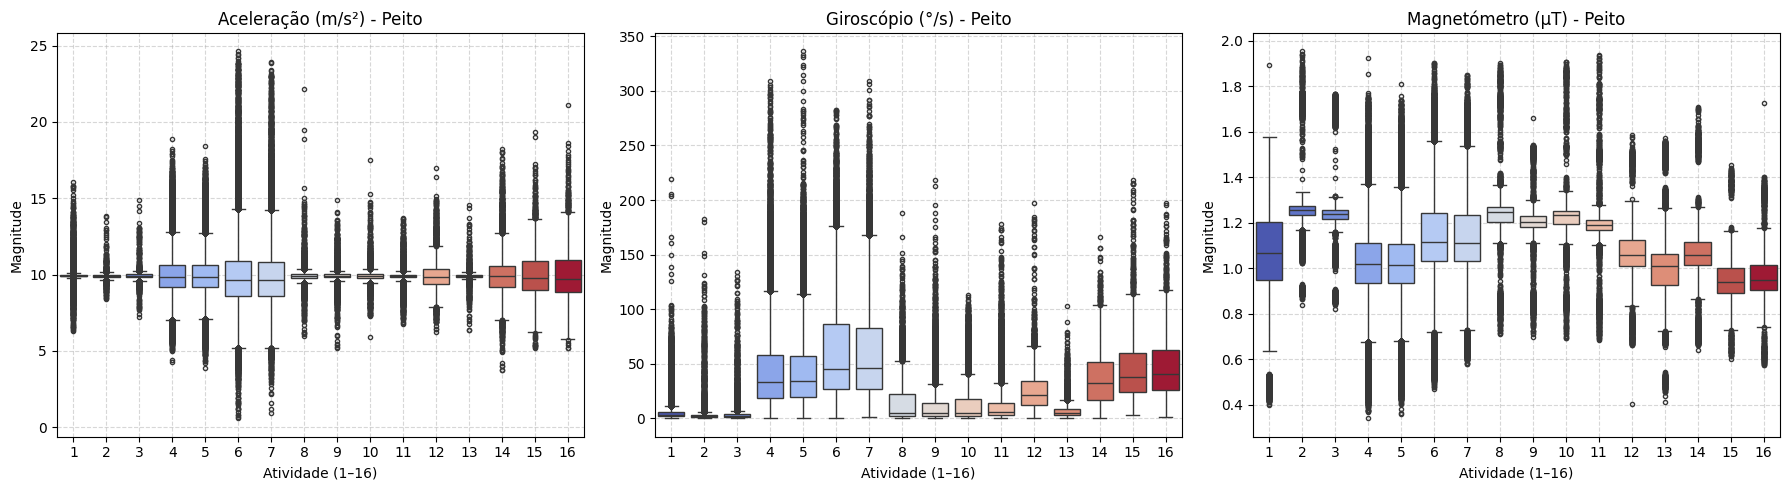

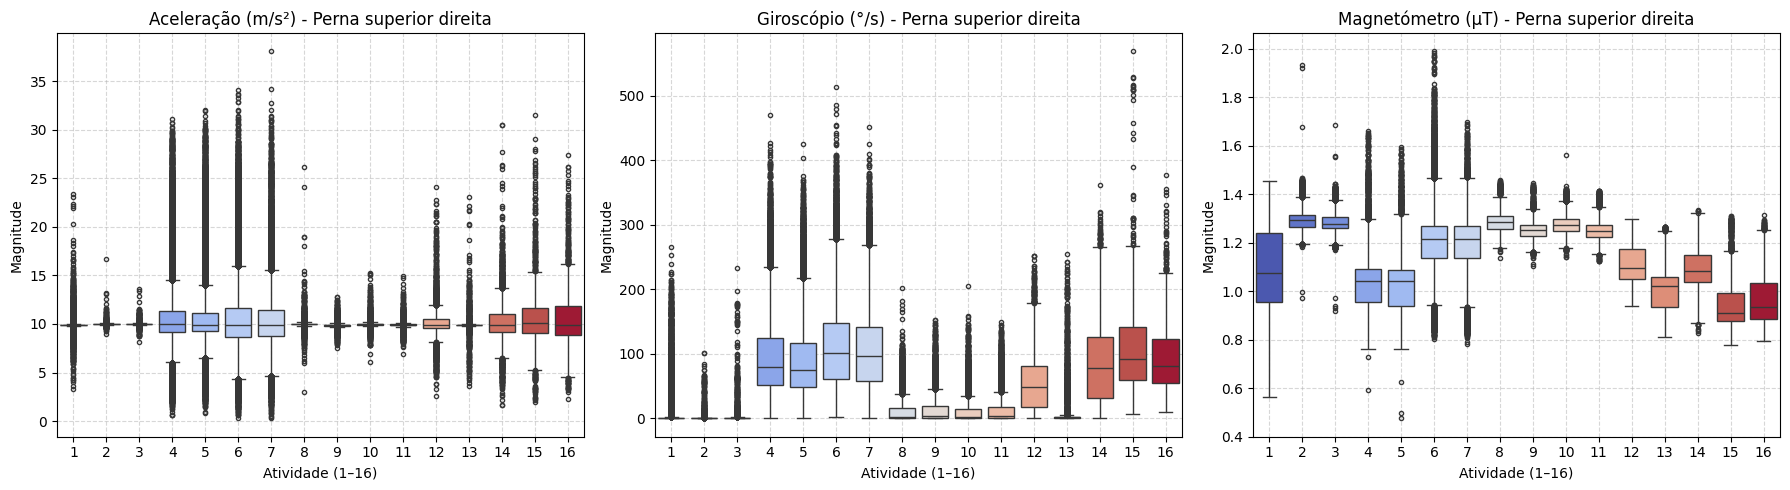

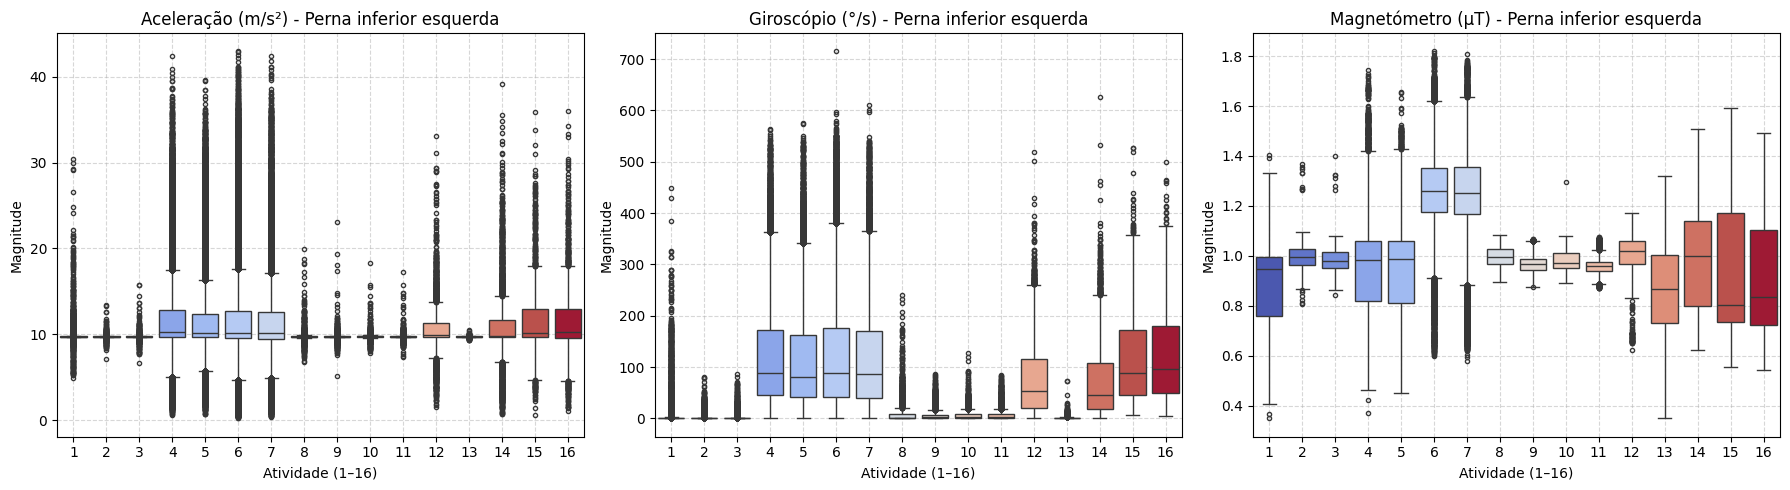

In [3]:
print("\n3.1 - Boxplots por atividade (Aceleração, Giroscópio e Magnetómetro)")
for device_id, device_name in devices.items():
        df_device = df[df["device"] == device_id]
        if df_device.empty:
            print(f"Atenção: nenhum dado para {device_name}")
            continue

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        for ax, (variable, label) in zip(axes, sensors.items()):
            df_valid = df_device[df_device[variable].notna() & df_device["activity"].notna()]
            if df_valid.empty:
                ax.text(0.5, 0.5, "Sem dados", ha="center", va="center", fontsize=12)
                ax.axis("off")
                continue

            sns.boxplot(
                data=df_valid,
                x="activity",
                y=variable,
                hue="activity",
                palette="coolwarm",
                legend=False,
                fliersize=3,
                ax=ax
            )
            ax.set_title(f"{label} - {device_name}")
            ax.set_xlabel("Atividade (1–16)")
            ax.set_ylabel("Magnitude")
            ax.grid(True, linestyle="--", alpha=0.5)

        plt.tight_layout()
        plt.show()


## 3.2 - Densidade de outliers

In [4]:
print("\n3.2 - Densidade de outliers (IQR/Tukey) - Pulso direito")
df_right_wrist = df[df['device'] == 2].copy()

if df_right_wrist.empty:
  print("Nenhum dado encontrado para o pulso direito (device == 2). Verifique 'df'.")
else:
  variables = ["acc_mag", "gyro_mag", "mag_mag"]
  labels = ["Aceleração", "Giroscópio", "Magnetómetro"]
  for variable, label in zip(variables, labels):
    print(f"\n--- {label} ---")
    try:
      densities = outlier_density_iqr(df_right_wrist, variable)
      print("Densidade de outliers por atividade:")
      print(densities)
      try:
        mean_density = densities.mean()
        max_activity = densities.idxmax()
        print(f"Densidade média: {mean_density:.4f} -- Atividade com maior densidade: {max_activity}")
      except Exception:
        pass
      try:
        densities.plot(kind='bar', title=f'Densidade de outliers - {label} (Pulso direito)')
        plt.xlabel('Atividade')
        plt.ylabel('Densidade de outliers')
        plt.show()
      except Exception as e:
        print('Não foi possível plotar:', e)
    except Exception as e:
      print('Erro ao calcular densidade para', variable, e)


3.2 - Densidade de outliers (IQR/Tukey) - Pulso direito

--- Aceleração ---
Atividade 1: 4.20% outliers
Atividade 2: 0.22% outliers
Atividade 3: 0.51% outliers
Atividade 4: 3.53% outliers
Atividade 5: 3.48% outliers
Atividade 6: 5.17% outliers
Atividade 7: 4.51% outliers
Atividade 8: 15.44% outliers
Atividade 9: 19.80% outliers
Atividade 10: 15.32% outliers
Atividade 11: 18.32% outliers
Atividade 12: 10.92% outliers
Atividade 13: 4.79% outliers
Atividade 14: 14.17% outliers
Atividade 15: 4.93% outliers
Atividade 16: 4.99% outliers
Densidade de outliers por atividade:
{np.int64(1): np.float64(4.195538440100835), np.int64(2): np.float64(0.21555830792682928), np.int64(3): np.float64(0.5138505520504733), np.int64(4): np.float64(3.530950305143853), np.int64(5): np.float64(3.4776561819535563), np.int64(6): np.float64(5.165680009847916), np.int64(7): np.float64(4.51462629307392), np.int64(8): np.float64(15.444711538461538), np.int64(9): np.float64(19.797585227272727), np.int64(10): np.float6

## 3.3 - Rotina Z-Score: recebe um array (serie) e um k, retorna (mask, z_scores)

In [5]:
def zscore_test(arr, k=3.0):
    """Retorna (mask, z_scores). mask=True para outliers."""
    arr = np.asarray(arr, dtype=float)
    mean = np.nanmean(arr)
    std = np.nanstd(arr)
    if std == 0 or np.isnan(std):
        z = np.zeros_like(arr)
        mask = np.zeros(len(arr), dtype=bool)
    else:
        z = (arr - mean) / std
        mask = np.abs(z) > k
    return mask, z


## 3.4 - Marcar amostras outliers (Z-score) para acc_mag, gyro_mag, mag_mag
Gera plots com outliers em vermelho e inliers em azul para k=3,3.5,4.

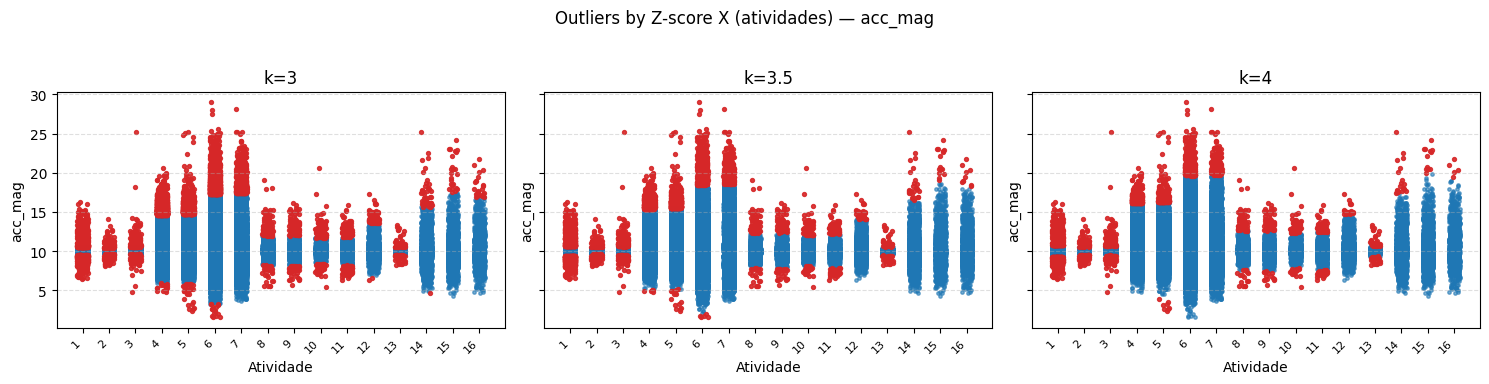

Resumo percentual — acc_mag (% outliers por atividade)


,n_samples,k_3,k_3.5,k_4
activity,,,,
11,5376,2.994792,2.194940,1.655506
9,5632,2.539062,1.882102,1.367188
10,6656,2.223558,1.487380,1.021635
12,3810,1.837270,1.023622,0.629921
8,6656,1.832933,1.367188,1.141827
7,43791,1.358727,0.666804,0.347103
14,3810,1.312336,0.734908,0.551181
6,89359,1.301492,0.641234,0.322295
15,1905,1.259843,0.787402,0.629921


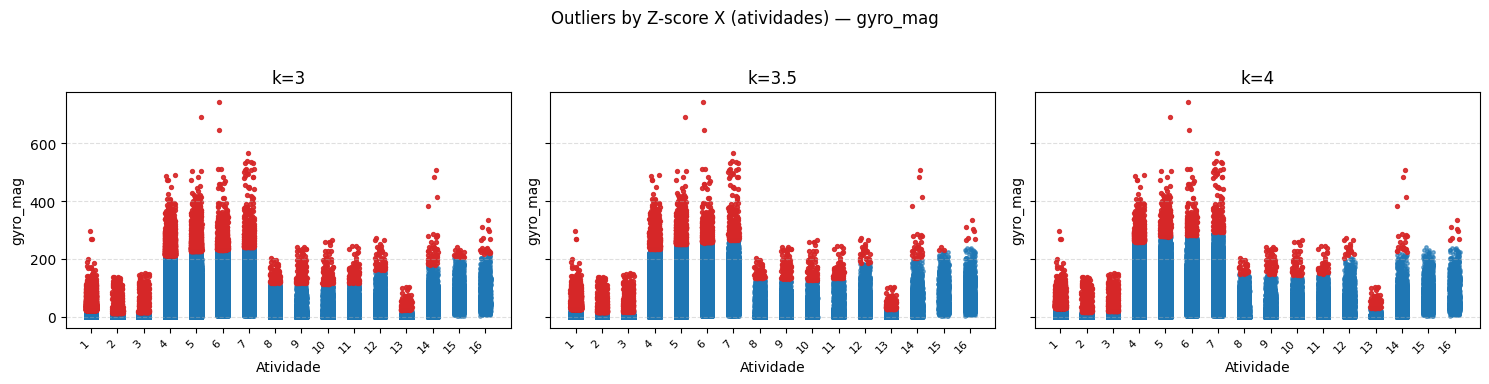

Resumo percentual — gyro_mag (% outliers por atividade)


,n_samples,k_3,k_3.5,k_4
activity,,,,
11,5376,2.511161,1.562500,0.892857
13,7620,2.467192,2.073491,1.574803
9,5632,2.183949,1.491477,1.065341
10,6656,2.118389,1.216947,0.751202
8,6656,1.832933,0.841346,0.405649
12,3810,1.627297,0.734908,0.446194
14,3810,1.548556,0.971129,0.603675
1,157882,1.487187,1.268669,1.104622
16,1905,1.154856,0.367454,0.367454


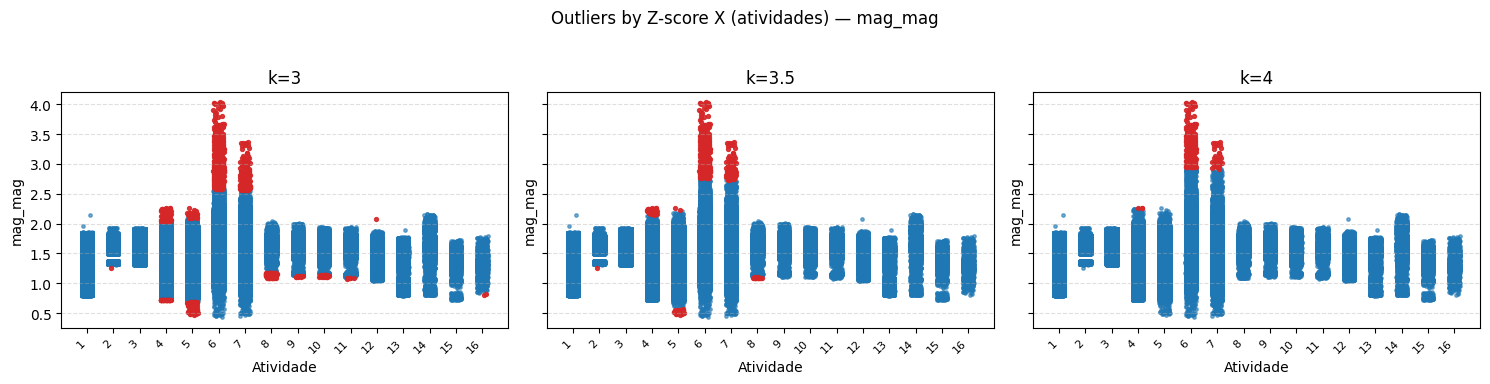

Resumo percentual — mag_mag (% outliers por atividade)


,n_samples,k_3,k_3.5,k_4
activity,,,,
8,6656,2.524038,0.240385,0.000000
6,89359,0.493515,0.360344,0.223816
10,6656,0.375601,0.000000,0.000000
7,43791,0.365372,0.203238,0.095910
9,5632,0.177557,0.000000,0.000000
11,5376,0.130208,0.000000,0.000000
16,1905,0.104987,0.000000,0.000000
4,139934,0.082896,0.029300,0.002144
5,142366,0.064622,0.019668,0.000000


In [6]:
k_list = [3, 3.5, 4]
variables = ['acc_mag', 'gyro_mag', 'mag_mag']

if 'df_right_wrist' not in globals():
    print("df_right_wrist não encontrado. Execute a célula 3.2 antes desta.")
else:
    np.random.seed(0)
    candidate_activity_cols = ['activity', 'activity_id', 'label']
    activity_col = next((c for c in candidate_activity_cols if c in df_right_wrist.columns), None)
    if activity_col is None:
        print("Coluna 'activity' não encontrada em df_right_wrist. Não é possível agrupar por atividade.")
    else:
        activities = list(np.unique(df_right_wrist[activity_col].values))
        try:
            activities = sorted(activities)
        except Exception:
            activities = list(activities)

        x_positions = np.arange(len(activities))
        labels = [str(a) for a in activities]

        for var in variables:
            fig, axes = plt.subplots(1, len(k_list), figsize=(5*len(k_list), 4), sharey=True)
            fig.suptitle(f'Outliers by Z-score X (atividades) — {var}')

            for i, act in enumerate(activities):
                df_a = df_right_wrist[df_right_wrist[activity_col] == act]
                if var not in df_a.columns or df_a.empty:
                    continue

                series_full = df_a[var].values.astype(float)
                if len(series_full) == 0:
                    continue
                series_to_plot = series_full
                jitter = np.random.uniform(-0.2, 0.2, size=len(series_to_plot))
                x_vals = np.full(len(series_to_plot), x_positions[i]) + jitter
                for ax, k in zip(axes, k_list):
                    try:
                        mask, _ = zscore_test(series_to_plot, k=k)
                    except Exception:
                        mask = np.zeros(len(series_to_plot), dtype=bool)
                    ax.scatter(x_vals[~mask], series_to_plot[~mask], c='tab:blue', s=6, alpha=0.6)
                    ax.scatter(x_vals[mask], series_to_plot[mask], c='tab:red', s=8, alpha=0.9)

            for ax, k in zip(axes, k_list):
                ax.set_title(f'k={k}')
                ax.set_xticks(x_positions)
                ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
                ax.set_xlabel('Atividade')
                ax.set_ylabel(var)
                ax.grid(axis='y', linestyle='--', alpha=0.4)

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()
            plt.close('all')

            try:
                perc_summary = []
                for act in activities:
                    df_a = df_right_wrist[df_right_wrist[activity_col] == act]
                    if var not in df_a.columns or df_a.empty:
                        continue
                    series_full = df_a[var].values.astype(float)
                    n_full = len(series_full)
                    row = {'activity': str(act), 'n_samples': n_full}
                    for k in k_list:
                        mask, _ = zscore_test(series_full, k=k)
                        pct = 100.0 * mask.sum() / n_full if n_full > 0 else np.nan
                        row[f'k_{k}'] = pct
                    perc_summary.append(row)
                if perc_summary:
                    perc_df = pd.DataFrame(perc_summary).set_index('activity')
                    print(f"Resumo percentual — {var} (% outliers por atividade)")
                    display(perc_df.sort_values(by=f'k_{k_list[0]}', ascending=False).head(10))
            except Exception as e:
                print('Erro ao gerar resumo:', e)


## 3.6/3.7 - K-Means Clustering


3.6 - K-Means Clustering e Outliers

Aceleração - K-Means com 2 clusters


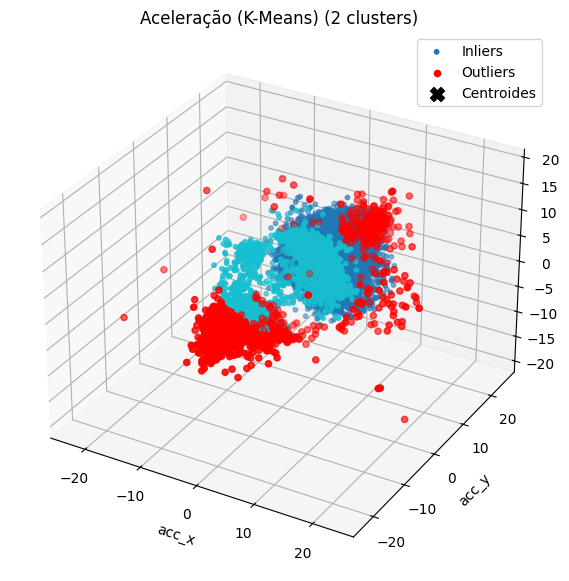

Detetados 12582 outliers de 781822 pontos (~1.61%)

Aceleração - K-Means com 3 clusters


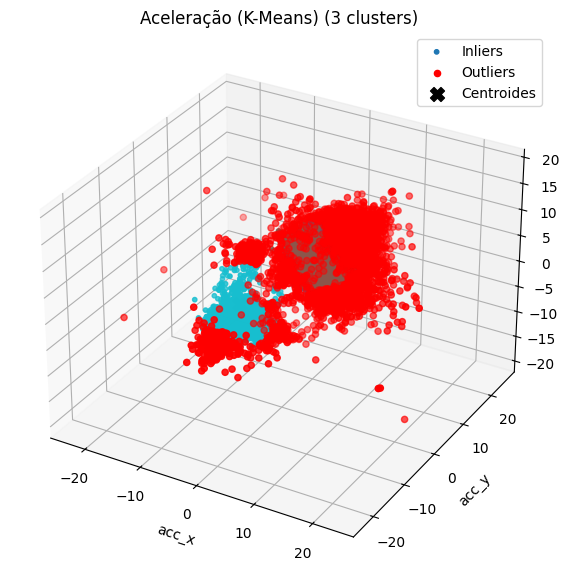

Detetados 16303 outliers de 781822 pontos (~2.09%)

Aceleração - K-Means com 4 clusters


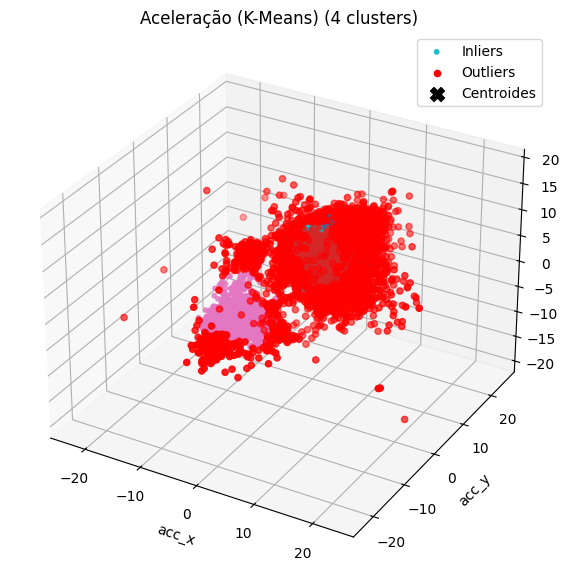

Detetados 14517 outliers de 781822 pontos (~1.86%)

Giroscópio - K-Means com 2 clusters


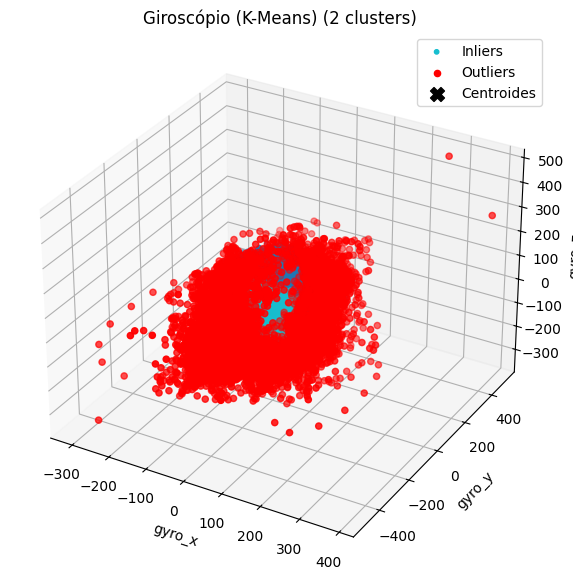

Detetados 13232 outliers de 781822 pontos (~1.69%)

Giroscópio - K-Means com 3 clusters


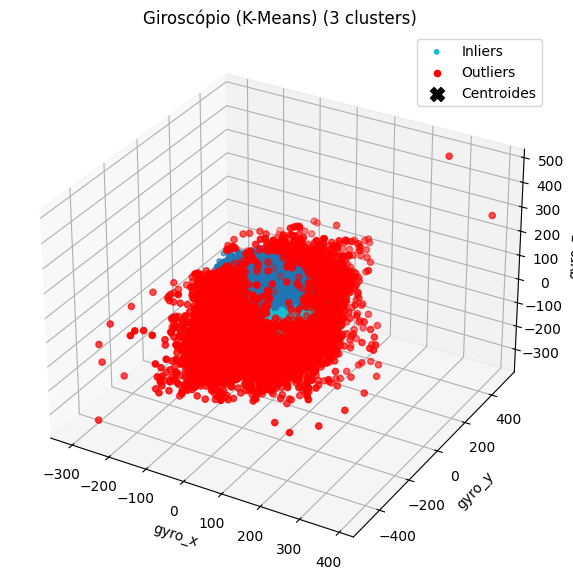

Detetados 15855 outliers de 781822 pontos (~2.03%)

Giroscópio - K-Means com 4 clusters


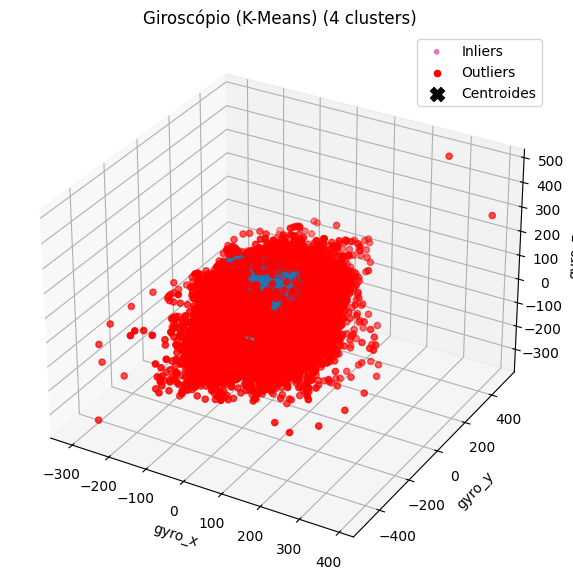

Detetados 11392 outliers de 781822 pontos (~1.46%)

Magnetómetro - K-Means com 2 clusters


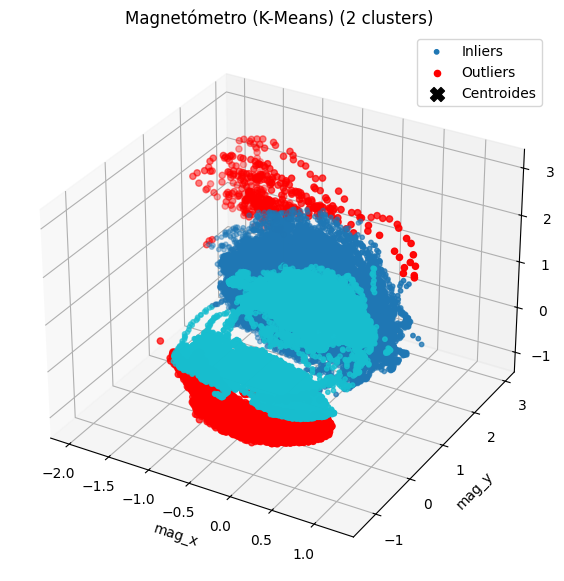

Detetados 21811 outliers de 781822 pontos (~2.79%)

Magnetómetro - K-Means com 3 clusters


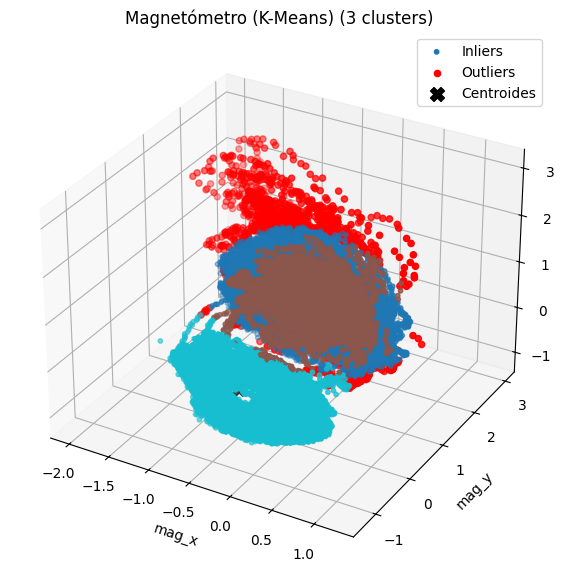

Detetados 1169 outliers de 781822 pontos (~0.15%)

Magnetómetro - K-Means com 4 clusters


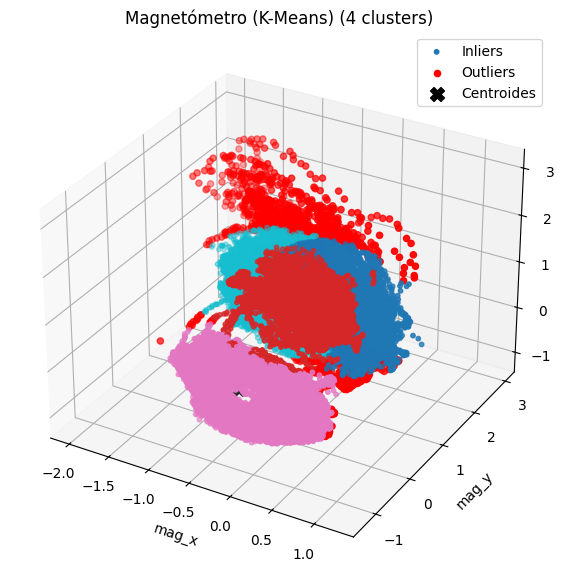

Detetados 2129 outliers de 781822 pontos (~0.27%)


In [7]:
print("\n3.6 - K-Means Clustering e Outliers")

sensor_spaces = {
  "Aceleração": ["acc_x", "acc_y", "acc_z"],
  "Giroscópio": ["gyro_x", "gyro_y", "gyro_z"],
  "Magnetómetro": ["mag_x", "mag_y", "mag_z"]
}

for sensor_name, variables in sensor_spaces.items():
  for n_clusters in [2, 3, 4]:
      print(f"\n{sensor_name} - K-Means com {n_clusters} clusters")
      kmeans_outliers(df_right_wrist, variables, n_clusters=n_clusters, title=f"{sensor_name} (K-Means)")

## 3.7.1 - DBSCAN


--- DBSCAN: Aceleração — variáveis: ['acc_x', 'acc_y', 'acc_z'] ---
Dataset grande (781822). Usando amostra de 50000 pontos...
Samples: 50000 -- Clusters: 3 -- Outliers: 202 (0.40%)


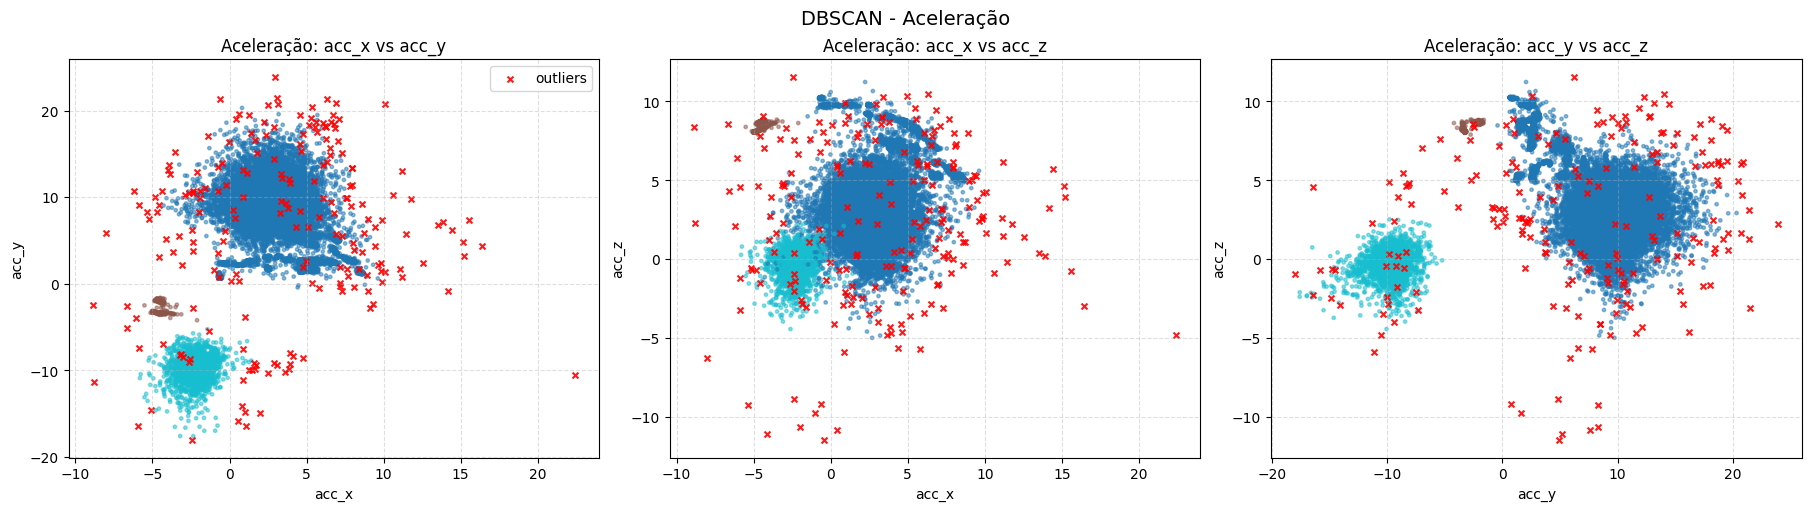

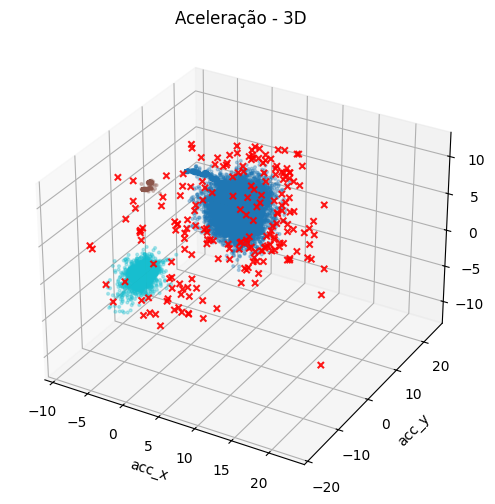


--- DBSCAN: Giroscópio — variáveis: ['gyro_x', 'gyro_y', 'gyro_z'] ---
Dataset grande (781822). Usando amostra de 50000 pontos...
Samples: 50000 -- Clusters: 2 -- Outliers: 1074 (2.15%)


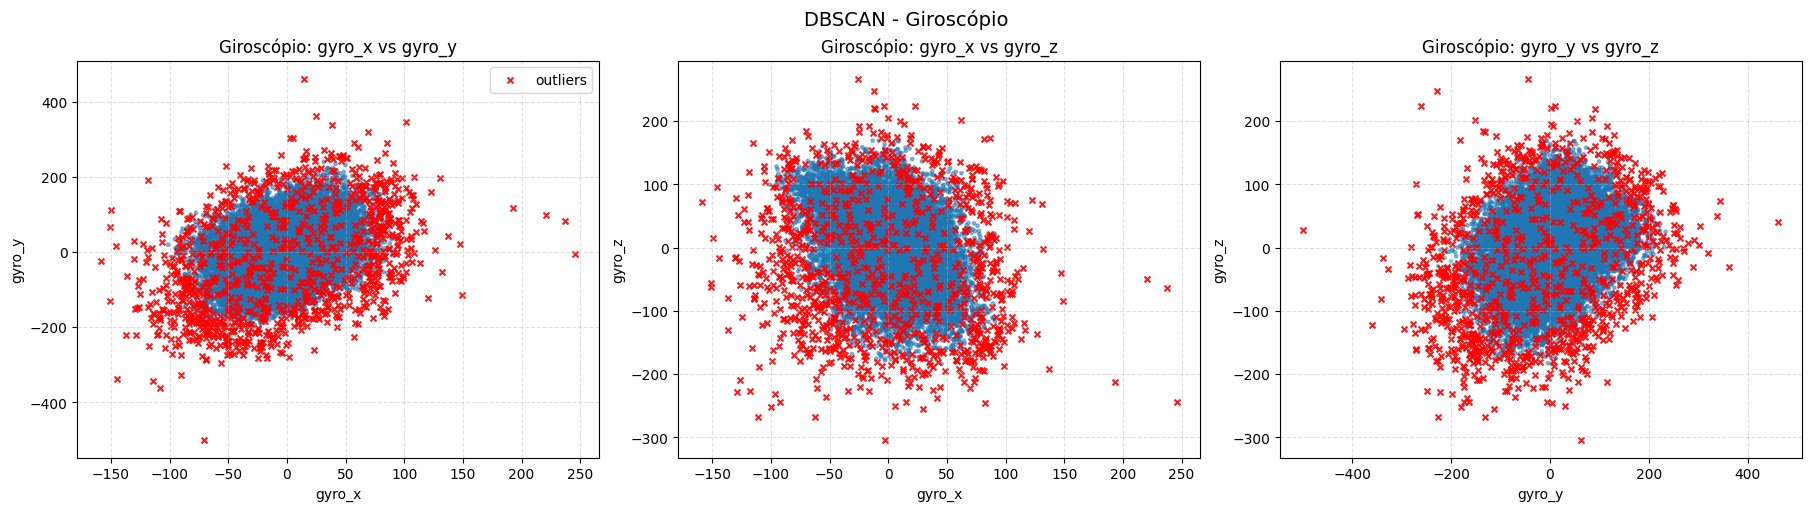

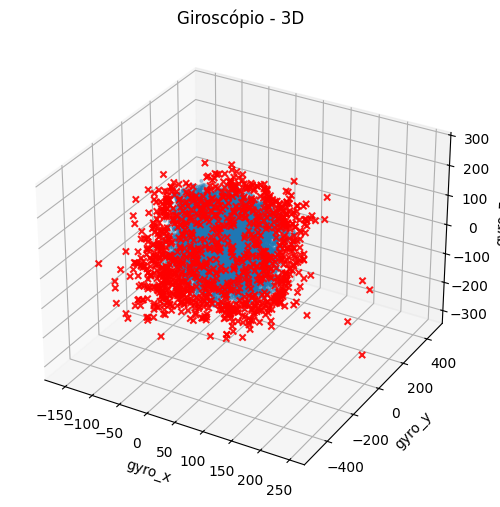


--- DBSCAN: Magnetómetro — variáveis: ['mag_x', 'mag_y', 'mag_z'] ---
Dataset grande (781822). Usando amostra de 50000 pontos...
Samples: 50000 -- Clusters: 2 -- Outliers: 46 (0.09%)


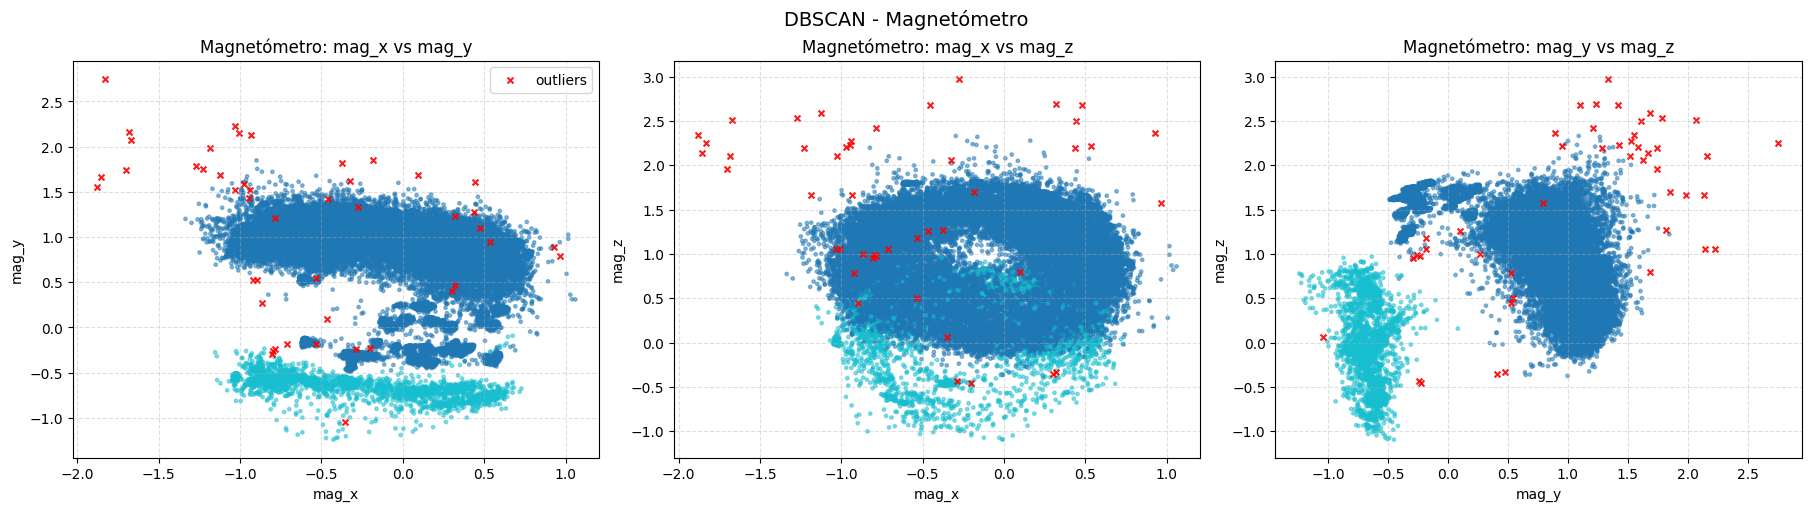

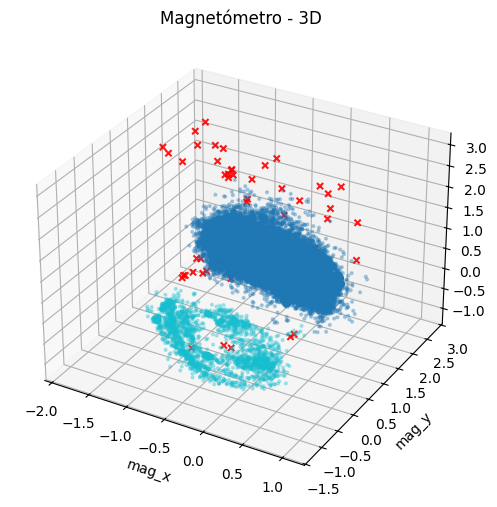

In [8]:
sensor_spaces = {
    "Aceleração": ['acc_x', 'acc_y', 'acc_z'],
    "Giroscópio": ['gyro_x', 'gyro_y', 'gyro_z'],
    "Magnetómetro": ['mag_x', 'mag_y', 'mag_z']
}

MAX_SAMPLES = 50000 

for sensor_name, vars3 in sensor_spaces.items():
    print(f"\n--- DBSCAN: {sensor_name} — variáveis: {vars3} ---")
    if 'df_right_wrist' not in locals():
         if 'df' in locals():
             df_use = df[df['device'] == 2].copy()
         else:
             print("ERRO: Dataframe não encontrado.")
             break
    else:
        df_use = df_right_wrist

    if not all(col in df_use.columns for col in vars3):
        print("Colunas faltando:", [c for c in vars3 if c not in df_use.columns])
        continue
        
    df_s = df_use.dropna(subset=vars3)
    
    if df_s.empty:
        print("Sem dados válidos para este sensor.")
        continue

    if len(df_s) > MAX_SAMPLES:
        print(f"Dataset grande ({len(df_s)}). Usando amostra de {MAX_SAMPLES} pontos...")
        df_s = df_s.sample(n=MAX_SAMPLES, random_state=42)

    X = df_s[vars3].values
    
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    dbscan = DBSCAN(eps=0.5, min_samples=10, n_jobs=-1)
    labels = dbscan.fit_predict(Xs)

    n_outliers = (labels == -1).sum()
    pct_outliers = 100.0 * n_outliers / len(labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"Samples: {len(labels)} -- Clusters: {n_clusters} -- Outliers: {n_outliers} ({pct_outliers:.2f}%)")

    # Plots 2D
    pairs = [ (0,1), (0,2), (1,2) ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    
    for ax, (i, j) in zip(axes, pairs):
        mask_inliers = labels != -1
        ax.scatter(X[mask_inliers, i], X[mask_inliers, j], c=labels[mask_inliers], cmap="tab10", s=6, alpha=0.5)
        
        mask_outliers = labels == -1
        if mask_outliers.any():
            ax.scatter(X[mask_outliers, i], X[mask_outliers, j], c='red', s=18, marker='x', alpha=0.9, label='outliers')
            
        ax.set_xlabel(vars3[i])
        ax.set_ylabel(vars3[j])
        ax.set_title(f"{sensor_name}: {vars3[i]} vs {vars3[j]}")
        ax.grid(True, linestyle='--', alpha=0.4)
        if i==0 and j==1: ax.legend()

    plt.suptitle(f"DBSCAN - {sensor_name}", fontsize=14)
    plt.show()

    # Plot 3D
    try:
        fig3 = plt.figure(figsize=(8, 6))
        ax3 = fig3.add_subplot(111, projection='3d')
        p = ax3.scatter(X[labels!=-1, 0], X[labels!=-1, 1], X[labels!=-1, 2], c=labels[labels!=-1], cmap="tab10", s=4, alpha=0.3)
        if (labels == -1).any():
            ax3.scatter(X[labels==-1, 0], X[labels==-1, 1], X[labels==-1, 2], c='red', s=20, marker='x', alpha=0.9)
        ax3.set_xlabel(vars3[0]); ax3.set_ylabel(vars3[1]); ax3.set_zlabel(vars3[2])
        ax3.set_title(f"{sensor_name} - 3D")
        plt.show()
    except Exception as e:
        print(f"Erro no plot 3D: {e}")

## 4.1 - Significância Estatística (para todos os dispositivos)

In [9]:
print("\n--- 4.1 - Análise de Significância Estatística por Dispositivo ---")
for device_id, device_name in devices.items():
  df_device = df[df["device"] == device_id]
  if df_device.empty:
      continue
  print(f"\n===== Análise de Significância para: {device_name} =====")
  for variable, label in zip(variables, labels_sensores):
    analyze_statistical_significance(df_device, variable, label)


--- 4.1 - Análise de Significância Estatística por Dispositivo ---

===== Análise de Significância para: Pulso esquerdo =====

--- 4.1 - Análise de Significância Estatística para Aceleração (m/s²) (mag_x) ---

Testes de Normalidade (Kolmogorov-Smirnov) para cada atividade:
  Atividade 'Climb Stair (up/down)' (90127 amostras): p-value = 0.0000 (Não Normal)
  Atividade 'Climb Stair (up/down) and talk' (45071 amostras): p-value = 0.0000 (Não Normal)
  Atividade 'Climb stairs (up/down) -> walk' (1905 amostras): p-value = 0.0000 (Não Normal)
  Atividade 'Climb stairs (up/down) and talk -> walk and talk' (1905 amostras): p-value = 0.0000 (Não Normal)
  Atividade 'Sit' (85632 amostras): p-value = 0.0000 (Não Normal)
  Atividade 'Sit and Talk' (83584 amostras): p-value = 0.0000 (Não Normal)
  Atividade 'Sit-> Stand' (5888 amostras): p-value = 0.0000 (Não Normal)
  Atividade 'Sit->Stand and talk' (5888 amostras): p-value = 0.0000 (Não Normal)
  Atividade 'Stand' (162125 amostras): p-value = 0.

## 4.2 - Extração de Features

In [10]:
#em feature_extraction.py na funcao extract_features_pipeline_multivariate alteramos de participant_id para participant por causa do erro que dava na execucao
print("Iniciar a extração de features para todos os participantes...")
features_df = extract_features_pipeline_multivariate(df, window_size=200, stride=100)

if features_df is None or features_df.empty:
    print("Nenhuma feature foi extraída.")
else:
    features_df.to_csv("features_dataset_multivariada.csv", index=False)
    print("\nExtração de features multivariada completa! Salvo em 'features_dataset_multivariada.csv'.")

    features_df.to_csv("features_dataset.csv", index=False)
    print("Salvo também em 'features_dataset.csv'.")

Iniciar a extração de features para todos os participantes...
Processando Participante 0, Dispositivo 1: 530 janelas encontradas.
Processando Participante 0, Dispositivo 2: 527 janelas encontradas.
Processando Participante 0, Dispositivo 3: 530 janelas encontradas.
Processando Participante 0, Dispositivo 4: 530 janelas encontradas.
Processando Participante 0, Dispositivo 5: 530 janelas encontradas.
Processando Participante 1, Dispositivo 1: 532 janelas encontradas.
Processando Participante 1, Dispositivo 2: 532 janelas encontradas.
Processando Participante 1, Dispositivo 3: 528 janelas encontradas.
Processando Participante 1, Dispositivo 4: 532 janelas encontradas.
Processando Participante 1, Dispositivo 5: 519 janelas encontradas.
Processando Participante 2, Dispositivo 1: 531 janelas encontradas.
Processando Participante 2, Dispositivo 2: 531 janelas encontradas.
Processando Participante 2, Dispositivo 3: 531 janelas encontradas.
Processando Participante 2, Dispositivo 4: 531 janelas

## 4.3/4.4- Normalização das Features e PCA

In [11]:
normalized_features = normalize_features(features_df)

print("Aplicar PCA com análise da variância explicada...")
transformed_features, explained_variance, selected_components = apply_pca_with_analysis(
    normalized_features,
    n_components=None,
    explained_variance_threshold=0.75
)

print(f"Componentes selecionados para 75% da variância explicada: {selected_components}")
print(f"Variância explicada cumulativa: {np.cumsum(explained_variance) * 100}")

transformed_features.to_csv("pca_features_dataset.csv", index=False)
print("Transformações do PCA salvas em 'pca_features_dataset.csv'.")

Aplicar PCA com análise da variância explicada...
Componentes selecionados para 75% da variância explicada: 21
Variância explicada cumulativa: [ 32.300024    40.46203124  46.11892805  50.3115833   53.74851546
  56.40977812  58.46707172  60.37886441  62.1206059   63.61748442
  65.08457836  66.48832795  67.70419969  68.85669717  69.92922759
  70.95441288  71.93591438  72.88493442  73.76722444  74.60967363
  75.39362332  76.14532866  76.82958967  77.5017002   78.14120848
  78.7664005   79.36201769  79.93996503  80.50623063  81.05342411
  81.59016485  82.12280344  82.64828084  83.16531538  83.68106083
  84.19485705  84.68347535  85.15883978  85.62650322  86.0796849
  86.52173022  86.95595273  87.38097505  87.79073092  88.1959555
  88.59173691  88.97949316  89.3607405   89.73869682  90.10964229
  90.47376081  90.82815475  91.16990692  91.49971992  91.82164003
  92.13842773  92.4539531   92.76134194  93.06094241  93.35200941
  93.64134124  93.92283783  94.19788184  94.46824618  94.72965772
 

## 4.5 - Seleção de Features (Fisher e ReliefF)

In [13]:
 # Utilizamos métodos Fisher Score e ReliefF para identificar as features mais relevantes.

print("Fisher Score:")

labels = np.array(features_df['participant'])
fisher_scores = fisher_score(normalized_features, labels)

print("\nFisher Scores (Ordenados):")
print(fisher_scores)

print("\nReliefF:")
relief_scores = reliefF_optimized(normalized_features, labels, n_neighbors=10)

top_10_fisher = fisher_scores.head(10).index.tolist()
top_10_relief = relief_scores.head(10).index.tolist()

print("\nTop 10 Features - Fisher Score:")
print(top_10_fisher)

print("\nTop 10 Features - ReliefF:")
print(top_10_relief)

tmp = tempfile.gettempdir()
tmp_fisher = os.path.join(tmp, "fisher_scores.csv")
tmp_relief = os.path.join(tmp, "reliefF_scores.csv")
try:
    fisher_scores.to_csv(tmp_fisher, index=True)
    relief_scores.to_csv(tmp_relief, index=True)
    print(f"Arquivos salvos em: {tmp_fisher} e {tmp_relief}")
except Exception as e:
    print("Erro ao escrever os arquivos em diretório temporário:", e)

Fisher Score:

Fisher Scores (Ordenados):
participant                    8.075774e+30
gyro_y_mean                    9.319444e-02
gyro_y_median                  8.472999e-02
acc_y_median                   8.221783e-02
acc_y_mean                     8.204588e-02
                                   ...     
acc_mag_zcr                    0.000000e+00
mag_mag_zcr                    0.000000e+00
mag_mag_dominant_frequency     0.000000e+00
acc_mag_dominant_frequency     0.000000e+00
gyro_mag_dominant_frequency    0.000000e+00
Length: 195, dtype: float64

ReliefF:

Top 10 Features - Fisher Score:
['participant', 'gyro_y_mean', 'gyro_y_median', 'acc_y_median', 'acc_y_mean', 'acc_y_min', 'acc_mag_variance', 'mag_y_energy', 'acc_y_max', 'acc_y_variance']

Top 10 Features - ReliefF:
['participant', 'acc_x_mean', 'acc_x_median', 'acc_x_rms', 'acc_z_rms', 'acc_z_mean', 'acc_z_median', 'mag_y_rms', 'mag_y_energy', 'acc_x_energy']
Arquivos salvos em: /var/folders/50/xm41lf691994b3kgc2pynbhw0000gn/T/f

## 4.6 - Comparação de Features Selecionadas

In [14]:
# top_10_fisher/top_10_relief são listas; use checagem de vazio compatível
if not top_10_fisher:
  print("Erro: top_10_fisher está vazio.")

if not top_10_relief:
  print("Erro: top_10_relief está vazio.")

common_features, fisher_exclusive, relief_exclusive = compare_top_features(top_10_fisher, top_10_relief)

print("Características comuns:", common_features)
print("Características exclusivas do Fisher:", fisher_exclusive)
print("Características exclusivas do Relief:", relief_exclusive)


compressed_features = get_compressed_features(normalized_features, top_10_fisher)
print("\nExemplo de Features Comprimidas (Fisher Score):")
print(compressed_features.head())

explain_feature_selection()

Características comuns: ['participant', 'mag_y_energy']
Características exclusivas do Fisher: ['acc_y_min', 'acc_y_median', 'acc_y_variance', 'gyro_y_mean', 'acc_y_mean', 'acc_y_max', 'acc_mag_variance', 'gyro_y_median']
Características exclusivas do Relief: ['acc_z_rms', 'acc_x_rms', 'acc_z_median', 'acc_x_energy', 'acc_x_mean', 'acc_x_median', 'mag_y_rms', 'acc_z_mean']

Exemplo de Features Comprimidas (Fisher Score):
   participant  gyro_y_mean  gyro_y_median  acc_y_median  acc_y_mean  \
0    -1.611729    -0.119398      -0.121775      0.356425    0.307045   
1    -1.611729    -0.106563      -0.099618      0.356666    0.309272   
2    -1.611729    -0.092456      -0.076373      0.360729    0.313806   
3    -1.611729    -0.092689      -0.090153      0.354754    0.310754   
4    -1.611729    -0.082412      -0.085971      0.357726    0.313740   

   acc_y_min  acc_mag_variance  mag_y_energy  acc_y_max  acc_y_variance  
0   0.900030         -0.580043     -0.690489  -0.470173       -0.6192

# Meta 2:


## 1. Data Augmentation

### 1.1 Preparação do Conjunto de Dados e Análise de Balanço de Classes

Shape do dataset completo: (39195, 195)
Primeiras 5 linhas do dataset completo:


,participant,device,activity,acc_x_mean,acc_x_std,acc_x_variance,acc_x_min,acc_x_max,acc_x_median,acc_x_amplitude,...,mag_mag_amplitude,mag_mag_kurtosis,mag_mag_skewness,mag_mag_rms,mag_mag_zcr,mag_mag_energy,mag_mag_dominant_frequency,mag_mag_entropy,mag_mag_bandwidth,mag_mag_centroid
0,0,1,1,-1.732536,0.092536,0.008563,-1.9791,-1.4694,-1.73160,0.5097,...,0.066295,-0.074729,-0.470974,1.229084,0.0,60425.941179,0.0,0.002215,0.135020,-0.002942
1,0,1,1,-1.719329,0.106987,0.011446,-1.9791,-1.2239,-1.72455,0.7552,...,0.065794,-0.238990,-0.451108,1.228165,0.0,60335.580520,0.0,0.002398,0.137717,-0.005939
2,0,1,1,-1.637473,0.187260,0.035066,-2.4817,-0.8698,-1.66535,1.6119,...,0.071433,0.268673,-0.623120,1.229242,0.0,60441.453435,0.0,0.002479,0.151468,-0.018723
3,0,1,1,-1.571226,0.177789,0.031609,-2.4817,-0.8698,-1.54875,1.6119,...,0.071552,1.055826,-0.852204,1.230073,0.0,60523.224607,0.0,0.002571,0.159353,-0.039014
4,0,1,1,-1.560458,0.058421,0.003413,-1.6841,-1.3883,-1.56630,0.2958,...,0.074612,0.970903,-0.821070,1.234351,0.0,60944.886153,0.0,0.002532,0.142626,-0.004057


Shape do dataset filtrado (Atividades 1-7): (37118, 195)
Primeiras 5 linhas do dataset filtrado:


,participant,device,activity,acc_x_mean,acc_x_std,acc_x_variance,acc_x_min,acc_x_max,acc_x_median,acc_x_amplitude,...,mag_mag_amplitude,mag_mag_kurtosis,mag_mag_skewness,mag_mag_rms,mag_mag_zcr,mag_mag_energy,mag_mag_dominant_frequency,mag_mag_entropy,mag_mag_bandwidth,mag_mag_centroid
0,0,1,1,-1.732536,0.092536,0.008563,-1.9791,-1.4694,-1.73160,0.5097,...,0.066295,-0.074729,-0.470974,1.229084,0.0,60425.941179,0.0,0.002215,0.135020,-0.002942
1,0,1,1,-1.719329,0.106987,0.011446,-1.9791,-1.2239,-1.72455,0.7552,...,0.065794,-0.238990,-0.451108,1.228165,0.0,60335.580520,0.0,0.002398,0.137717,-0.005939
2,0,1,1,-1.637473,0.187260,0.035066,-2.4817,-0.8698,-1.66535,1.6119,...,0.071433,0.268673,-0.623120,1.229242,0.0,60441.453435,0.0,0.002479,0.151468,-0.018723
3,0,1,1,-1.571226,0.177789,0.031609,-2.4817,-0.8698,-1.54875,1.6119,...,0.071552,1.055826,-0.852204,1.230073,0.0,60523.224607,0.0,0.002571,0.159353,-0.039014
4,0,1,1,-1.560458,0.058421,0.003413,-1.6841,-1.3883,-1.56630,0.2958,...,0.074612,0.970903,-0.821070,1.234351,0.0,60944.886153,0.0,0.002532,0.142626,-0.004057


Contagem de exemplos por atividade (1 a 7):
activity
1    7965
2    4224
3    4190
4    7000
5    7040
6    4463
7    2236
Name: count, dtype: int64

Número mínimo de amostras para uma atividade: 2236
Número máximo de amostras para uma atividade: 7965
Conclusão: O dataset é considerado desbalanceado, pois a proporção entre a atividade com mais exemplos e a com menos exemplos é maior que 2.


/var/folders/50/xm41lf691994b3kgc2pynbhw0000gn/T/ipykernel_12663/2623713990.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_balance.index, y=class_balance.values, palette='viridis')


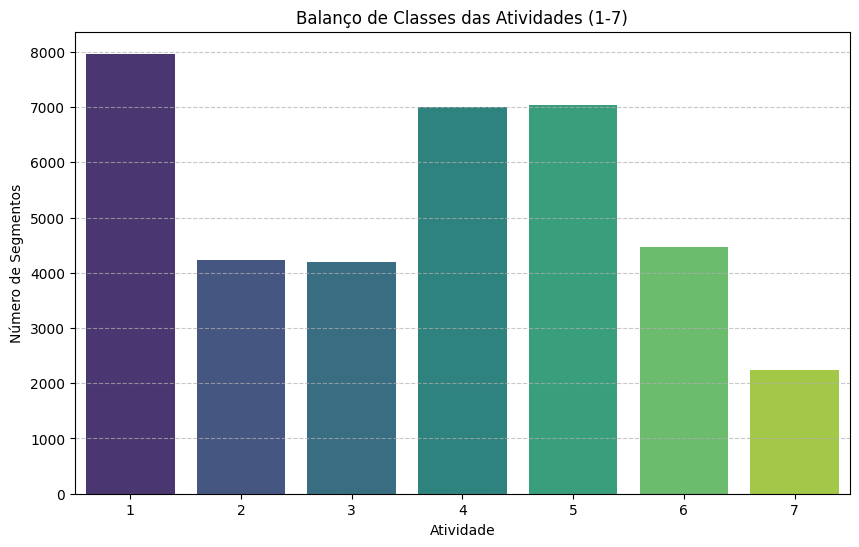

In [15]:

df_full_features = pd.read_csv('features_dataset_multivariada.csv')

print(f"Shape do dataset completo: {df_full_features.shape}")
print("Primeiras 5 linhas do dataset completo:")
display(df_full_features.head())


activities_of_interest = [1, 2, 3, 4, 5, 6, 7]

df_filtered = df_full_features[df_full_features['activity'].isin(activities_of_interest)].copy()

print(f"Shape do dataset filtrado (Atividades 1-7): {df_filtered.shape}")
print("Primeiras 5 linhas do dataset filtrado:")
display(df_filtered.head())

class_balance = df_filtered['activity'].value_counts().sort_index()

print("Contagem de exemplos por atividade (1 a 7):")
print(class_balance)

min_samples = class_balance.min()
max_samples = class_balance.max()
ratio = max_samples / min_samples if min_samples > 0 else float('inf')

print(f"\nNúmero mínimo de amostras para uma atividade: {min_samples}")
print(f"Número máximo de amostras para uma atividade: {max_samples}")

if ratio > 2:
    print("Conclusão: O dataset é considerado desbalanceado, pois a proporção entre a atividade com mais exemplos e a com menos exemplos é maior que 2.")
else:
    print("Conclusão: O dataset é considerado relativamente balanceado, pois a proporção entre a atividade com mais exemplos e a com menos exemplos é menor ou igual a 2.")

plt.figure(figsize=(10, 6))
sns.barplot(x=class_balance.index, y=class_balance.values, palette='viridis')
plt.title('Balanço de Classes das Atividades (1-7)')
plt.xlabel('Atividade')
plt.ylabel('Número de Segmentos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### 1.2/1.3 SMOTE, Geração e Visualização de Amostras Sintéticas

1.2/1.3 - SMOTE: VISUALIZAÇÃO E ANÁLISE DE SENSIBILIDADE

[A] Gerando 3 amostras sintéticas para visualização...


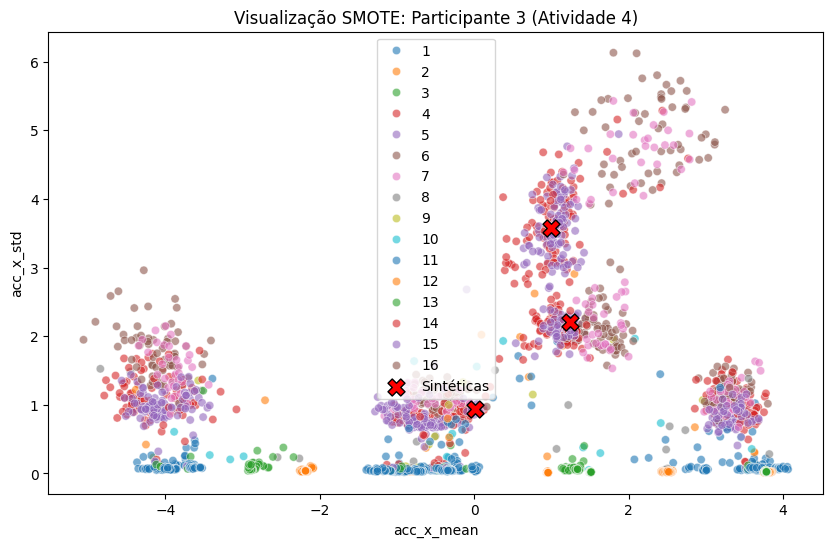


 [B] EXPERIMENTO: Impacto da quantidade de amostras na Accuracy
Testando quantidades: [0, 10, 30, 50, 100]...
-> +0 amostras | Acc: 0.6893 | Recall(4): 0.6702
-> +10 amostras | Acc: 0.6893 | Recall(4): 0.6702
-> +30 amostras | Acc: 0.6855 | Recall(4): 0.6702
-> +50 amostras | Acc: 0.6855 | Recall(4): 0.6809
-> +100 amostras | Acc: 0.6836 | Recall(4): 0.6809


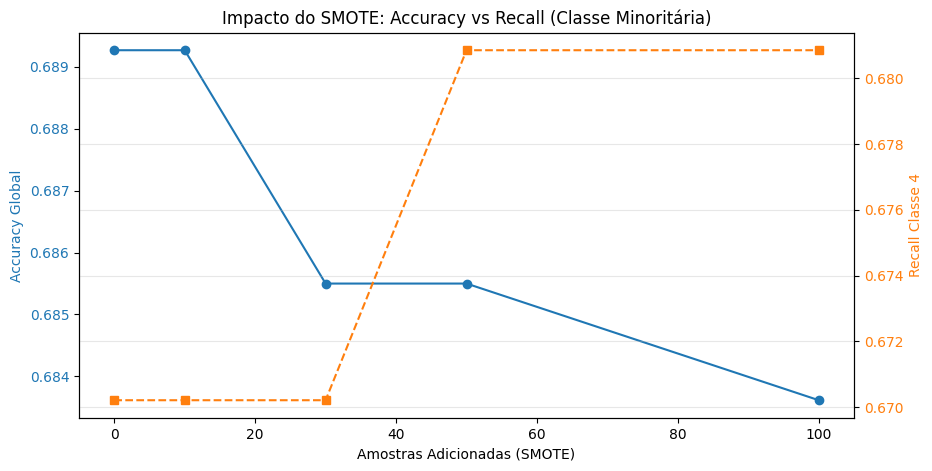

In [17]:

print("="*80)
print("1.2/1.3 - SMOTE: VISUALIZAÇÃO E ANÁLISE DE SENSIBILIDADE")
print("="*80)

if 'df_full_features' not in locals():
    print("'df_full_features' não está definido")

# PARTE A: Visualização
df_participant_3 = df_full_features[df_full_features['participant'].astype(str) == '3'].copy()

if df_participant_3.empty:
    print("DataFrame do participante 3 está vazio")
else:
    feature_columns = [col for col in df_participant_3.columns if col not in ['activity', 'participant', 'device']]
    X_p3 = df_participant_3[feature_columns]
    y_p3 = df_participant_3['activity']

    minority_class = 4  
    num_synthetic_samples_viz = 3

    print(f"\n[A] Gerando {num_synthetic_samples_viz} amostras sintéticas para visualização...")


    X_resampled_viz, y_resampled_viz = custom_smote(
        X_p3,
        y_p3,
        minority_class=minority_class,
        num_synthetic_samples_to_generate=num_synthetic_samples_viz,
        n_neighbors=5 
    )

    if len(X_resampled_viz) > len(X_p3):
        synthetic_indices = X_resampled_viz.index[-num_synthetic_samples_viz:]
        
        if len(feature_columns) >= 2:
            feat1 = feature_columns[0]
            feat2 = feature_columns[1] 
            
            plt.figure(figsize=(10, 6))
            sns.scatterplot(
                x=X_resampled_viz[feat1], y=X_resampled_viz[feat2],
                hue=y_resampled_viz, palette='tab10', alpha=0.6
            )
            plt.scatter(
                X_resampled_viz.loc[synthetic_indices, feat1],
                X_resampled_viz.loc[synthetic_indices, feat2],
                color='red', marker='X', s=150, edgecolors='black', label='Sintéticas'
            )
            plt.title(f'Visualização SMOTE: Participante 3 (Atividade {minority_class})')
            plt.legend()
            plt.show()

    
    # PARTE B: Análise de Sensibilidade
    print("\n" + "="*80)
    print(f" [B] EXPERIMENTO: Impacto da quantidade de amostras na Accuracy")
    print("="*80)

    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X_p3, y_p3, test_size=0.2, random_state=42, stratify=y_p3
        )
    except ValueError:
        print("Não foi possível estratificar")
        X_train, X_test, y_train, y_test = train_test_split(
            X_p3, y_p3, test_size=0.2, random_state=42
        )

    quantidades = [0, 10, 30, 50, 100] 
    resultados = []

    print(f"Testando quantidades: {quantidades}...")

    for n in quantidades:
        if n == 0:
            X_tr_final, y_tr_final = X_train, y_train
        else:
            try:
                X_tr_final, y_tr_final = custom_smote(
                    X_train, y_train, 
                    minority_class=minority_class, 
                    num_synthetic_samples_to_generate=n, 
                    n_neighbors=5
                )
            except Exception as e:
                print(f"Skip n={n}: {e}")
                continue

        # Treinar KNN
        knn = KNeighborsClassifier(n_neighbors=3) 
        knn.fit(X_tr_final, y_tr_final)
        y_pred = knn.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        
        key_min = str(minority_class) if str(minority_class) in report else int(minority_class)
        
        if key_min in report:
            recall_min = report[key_min]['recall']
        else:
            recall_min = 0.0 
        
        resultados.append({'N_Sinteticas': n, 'Accuracy': acc, 'Recall_Classe4': recall_min})
        print(f"-> +{n} amostras | Acc: {acc:.4f} | Recall(4): {recall_min:.4f}")

    # Plot Resultados
    if resultados:
        df_res = pd.DataFrame(resultados)
        
        fig, ax1 = plt.subplots(figsize=(10, 5))
        color = 'tab:blue'
        ax1.set_xlabel('Amostras Adicionadas (SMOTE)')
        ax1.set_ylabel('Accuracy Global', color=color)
        ax1.plot(df_res['N_Sinteticas'], df_res['Accuracy'], color=color, marker='o')
        ax1.tick_params(axis='y', labelcolor=color)

        ax2 = ax1.twinx()
        color = 'tab:orange'
        ax2.set_ylabel(f'Recall Classe {minority_class}', color=color)
        ax2.plot(df_res['N_Sinteticas'], df_res['Recall_Classe4'], color=color, marker='s', linestyle='--')
        ax2.tick_params(axis='y', labelcolor=color)

        plt.title('Impacto do SMOTE: Accuracy vs Recall (Classe Minoritária)')
        plt.grid(True, alpha=0.3)
        plt.show()

## 2. Embedding features

### 2.1 Preparação do FEATURES DATASET

In [18]:
try:
    if 'features_df' not in locals() or features_df is None:
        features_df = pd.read_csv("features_dataset.csv")
except FileNotFoundError:
    print("O ficheiro 'features_dataset.csv' não existe")

if 'features_df' in locals() and features_df is not None:
    print(f"Dimensões do Dataset: {features_df.shape} (Linhas, Colunas)")
    
    required_labels = ['participant_id', 'activity']
    missing_labels = [col for col in required_labels if col not in features_df.columns]
    
    if not missing_labels:
        print("Rótulos presentes: 'participant_id' e 'activity'.")
    else:
        print(f"Rótulos em falta: {missing_labels}")

    if features_df.isnull().values.any():
        print(f"Aviso: Existem {features_df.isnull().sum().sum()} valores nulos no dataset.")

    print("\n--- Primeiras 5 linhas do Features Dataset ---")
    display(features_df.head())
    
    print("\n--- Informações das Colunas ---")
    print(features_df.info())

Dimensões do Dataset: (39195, 195) (Linhas, Colunas)
Rótulos em falta: ['participant_id']

--- Primeiras 5 linhas do Features Dataset ---


,participant,device,activity,acc_x_mean,acc_x_std,acc_x_variance,acc_x_min,acc_x_max,acc_x_median,acc_x_amplitude,...,mag_mag_amplitude,mag_mag_kurtosis,mag_mag_skewness,mag_mag_rms,mag_mag_zcr,mag_mag_energy,mag_mag_dominant_frequency,mag_mag_entropy,mag_mag_bandwidth,mag_mag_centroid
0,0,1,1,-1.732536,0.092536,0.008563,-1.9791,-1.4694,-1.73160,0.5097,...,0.066295,-0.074729,-0.470974,1.229084,0.0,60425.941179,0.0,0.002215,0.135020,-0.002942
1,0,1,1,-1.719329,0.106987,0.011446,-1.9791,-1.2239,-1.72455,0.7552,...,0.065794,-0.238990,-0.451108,1.228165,0.0,60335.580520,0.0,0.002398,0.137717,-0.005939
2,0,1,1,-1.637473,0.187260,0.035066,-2.4817,-0.8698,-1.66535,1.6119,...,0.071433,0.268673,-0.623120,1.229242,0.0,60441.453435,0.0,0.002479,0.151468,-0.018723
3,0,1,1,-1.571226,0.177789,0.031609,-2.4817,-0.8698,-1.54875,1.6119,...,0.071552,1.055826,-0.852204,1.230073,0.0,60523.224607,0.0,0.002571,0.159353,-0.039014
4,0,1,1,-1.560458,0.058421,0.003413,-1.6841,-1.3883,-1.56630,0.2958,...,0.074612,0.970903,-0.821070,1.234351,0.0,60944.886153,0.0,0.002532,0.142626,-0.004057



--- Informações das Colunas ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39195 entries, 0 to 39194
Columns: 195 entries, participant to mag_mag_centroid
dtypes: float64(192), int64(3)
memory usage: 58.3 MB
None


### 2.2 Geração do EMBEDDINGS DATASET

In [19]:
if 'df' not in locals():
    print("O dataframe 'df' não está carregado")
else:
    activities_of_interest = [1, 2, 3, 4, 5, 6, 7]
    df_full_filtered = df[df['activity'].isin(activities_of_interest)].copy()

    print(f"Shape do DF Filtrado: {df_full_filtered.shape}")

    INPUT_FS = 50.0      
    WINDOW_SEC = 5.0      
    STRIDE_SEC = 2.5      

    print(f"\n>>> 2. Iniciando extração de Embeddings...")
    print(f"Configuração: Window={WINDOW_SEC}s, Stride={STRIDE_SEC}s")

    df_embeddings = generate_embeddings_dataset(
        df_full_filtered, 
        input_fs=INPUT_FS, 
        window_sec=WINDOW_SEC, 
        stride_sec=STRIDE_SEC
    )


    if df_embeddings is not None:        
        print(f"Dimensões Embeddings: {df_embeddings.shape}")
        
        if 'features_df' in locals():
            n_feat = len(features_df)
            n_emb = len(df_embeddings)
            diff = abs(n_feat - n_emb)
            
            print(f"Segmentos no Features Dataset:   {n_feat}")
            print(f"Segmentos no Embeddings Dataset: {n_emb}")
            
            if diff == 0:
                print("Os datasets estão perfeitamente alinhados!")
            elif diff < 50: 
                print(f"AVISO: Pequena diferença de {diff} segmentos (arredondamento). Aceitável.")
                min_len = min(n_feat, n_emb)
                features_df = features_df.iloc[:min_len]
                df_embeddings = df_embeddings.iloc[:min_len]
                print(f"-> Datasets ajustados para {min_len} linhas.")
                features_df.to_csv("features_dataset.csv", index=False)
            else:
                print(f"Diferença de {diff} segmentos.Volte ao passo 2.1 e use window=250 e stride=125.")

        df_embeddings.to_csv("embeddings_dataset.csv", index=False)
        print("\n Ficheiro 'embeddings_dataset.csv' guardado")


Shape do DF Filtrado: (3718503, 16)

>>> 2. Iniciando extração de Embeddings...
Configuração: Window=5.0s, Stride=2.5s
--- Iniciando geração de Embeddings (Input FS: 50.0Hz -> Target: 30Hz) ---


Using cache found in /Users/lucianarocha/.cache/torch/hub/OxWearables_ssl-wearables_main


131 Weights loaded
Extraindo embeddings para 29636 segmentos...
Shape ajustado para 2D: (29636, 512)
Dataset de Embeddings gerado com shape: (29636, 515)
Dimensões Embeddings: (29636, 515)
Segmentos no Features Dataset:   39195
Segmentos no Embeddings Dataset: 29636
Diferença de 9559 segmentos.Volte ao passo 2.1 e use window=250 e stride=125.

 Ficheiro 'embeddings_dataset.csv' guardado


## 3. Data splitting strategy 

### 3.1 Divisão Intra-Sujeito (Within-Subject):
### 3.2 Divisão Inter-Sujeitos (Between-Subjects):

In [23]:
# FUNÇÕES DE APOIO AO SPLIT (3.1 e 3.2)
def perform_within_split(df, dataset_name="Dataset"):
    print(f"\n--- 3.1 Divisão Intra-Sujeito: {dataset_name} ---")
    
    splits = split_within_subject(df, train_ratio=0.6, val_ratio=0.2, test_ratio=0.2,)# mudar 
    
    n_total = len(df)
    n_train = len(splits['train'])
    n_val = len(splits['val'])
    n_test = len(splits['test'])
    
    print(f"Tamanhos: Treino={n_train} ({n_train/n_total:.1%}) | Val={n_val} ({n_val/n_total:.1%}) | Teste={n_test} ({n_test/n_total:.1%})")
    
    parts_train = set(splits['train']['participant_id'].unique())
    parts_test = set(splits['test']['participant_id'].unique())
    common = parts_train.intersection(parts_test)
    
    if len(common) > 0:
        print(f"VALIDAÇÃO: OK. {len(common)} participantes comuns encontrados (Correto para Intra-Sujeito).")
    return splits

def perform_between_split(df, dataset_name="Dataset"):
    print(f"\n--- 3.2 Divisão Inter-Sujeitos: {dataset_name} ---")
    
    splits = split_between_subjects(df, n_train=9, n_val=3, n_test=3)
    
    print(f"Tamanhos: Treino={len(splits['train'])} | Val={len(splits['val'])} | Teste={len(splits['test'])}")
    
    ids_train = set(splits['train']['participant_id'].unique())
    ids_val = set(splits['val']['participant_id'].unique())
    ids_test = set(splits['test']['participant_id'].unique())
    
    print(f"IDs Treino: {sorted(list(ids_train))}")
    print(f"IDs Teste:  {sorted(list(ids_test))}")
    
    leakage = ids_train.intersection(ids_test).union(ids_train.intersection(ids_val))
    
    if len(leakage) == 0:
        print("VALIDAÇÃO: OK. Participantes totalmente isolados (Correto para Inter-Sujeitos).") 
    return splits


## EXECUÇÃO DOS SPLITS

if 'features_df' not in locals():
    features_df = pd.read_csv("features_dataset.csv")

if 'participant' in features_df.columns:
    features_df = features_df.rename(columns={'participant': 'participant_id'})
    print("Correção: 'participant' renomeada para 'participant_id' em features_df")

if 'embeddings_df' not in locals():
    if 'df_embeddings' in locals():
        embeddings_df = df_embeddings
    else:
        embeddings_df = pd.read_csv("embeddings_dataset.csv")

if 'participant' in embeddings_df.columns:
    embeddings_df = embeddings_df.rename(columns={'participant': 'participant_id'})

splits_features_within = perform_within_split(features_df, "Features")
splits_features_between = perform_between_split(features_df, "Features")

splits_embeddings_within = perform_within_split(embeddings_df, "Embeddings")
splits_embeddings_between = perform_between_split(embeddings_df, "Embeddings")

Correção: 'participant' renomeada para 'participant_id' em features_df

--- 3.1 Divisão Intra-Sujeito: Features ---
--- Divisão Intra-Sujeito (Stratified Shuffle) ---
Treino: 23517 | Validação: 7839 | Teste: 7839
Tamanhos: Treino=23517 (60.0%) | Val=7839 (20.0%) | Teste=7839 (20.0%)
VALIDAÇÃO: OK. 15 participantes comuns encontrados (Correto para Intra-Sujeito).

--- 3.2 Divisão Inter-Sujeitos: Features ---
--- Divisão Inter-Sujeitos (Split por Participante) ---
IDs Treino (9): [ 9 11  0 13  5  8  2  1 14]
IDs Validação (3): [ 4  7 10]
IDs Teste (3): [12  3  6]
Amostras -> Treino: 23529 | Validação: 7696 | Teste: 7970
Tamanhos: Treino=23529 | Val=7696 | Teste=7970
IDs Treino: [np.int64(0), np.int64(1), np.int64(2), np.int64(5), np.int64(8), np.int64(9), np.int64(11), np.int64(13), np.int64(14)]
IDs Teste:  [np.int64(3), np.int64(6), np.int64(12)]
VALIDAÇÃO: OK. Participantes totalmente isolados (Correto para Inter-Sujeitos).

--- 3.1 Divisão Intra-Sujeito: Embeddings ---
--- Divisão In

### 3.4 Processamento de Cenários

In [24]:
if 'features_df' not in locals():
    features_df = pd.read_csv("features_dataset.csv")
if 'embeddings_df' not in locals():
    embeddings_df = pd.read_csv("embeddings_dataset.csv")

ACTIVITIES_MAIN = [1, 2, 3, 4, 5, 6, 7]  

if 'activity' in features_df.columns:
    features_df = features_df[features_df['activity'].isin(ACTIVITIES_MAIN)].copy()
    print(f"Features: {len(features_df)} amostras após filtro (7 atividades)")

if 'activity' in embeddings_df.columns:
    embeddings_df = embeddings_df[embeddings_df['activity'].isin(ACTIVITIES_MAIN)].copy()
    print(f"Embeddings: {len(embeddings_df)} amostras após filtro (7 atividades)")

print("\n ETAPA 1: Gerar Splits")

# 1. Divisão Intra-Sujeito
print("Splits Intra-Sujeito")
splits_features_within = split_within_subject(features_df)
splits_embeddings_within = split_within_subject(embeddings_df)

# 2. Divisão Inter-Sujeitos
print("Splits Inter-Sujeitos")
splits_features_between = split_between_subjects(features_df, n_train=9, n_val=3, n_test=3)
splits_embeddings_between = split_between_subjects(embeddings_df, n_train=9, n_val=3, n_test=3)


print("\n ETAPA 2: Processar Cenários")
scenarios_features_within = process_split_scenarios(splits_features_within, "Features (Within)")
scenarios_features_between = process_split_scenarios(splits_features_between, "Features (Between)")

scenarios_embeddings_within = process_split_scenarios(splits_embeddings_within, "Embeddings (Within)")
scenarios_embeddings_between = process_split_scenarios(splits_embeddings_between, "Embeddings (Between)")


print("\n ETAPA 3: Criar objeto final 'master_data'")

master_data = {
    'features': {
        'within': scenarios_features_within,
        'between': scenarios_features_between
    },
    'embeddings': {
        'within': scenarios_embeddings_within,
        'between': scenarios_embeddings_between
    }
}

Features: 37118 amostras após filtro (7 atividades)
Embeddings: 29636 amostras após filtro (7 atividades)

 ETAPA 1: Gerar Splits
Splits Intra-Sujeito
--- Divisão Intra-Sujeito (Stratified Shuffle) ---
Treino: 22270 | Validação: 7424 | Teste: 7424
--- Divisão Intra-Sujeito (Stratified Shuffle) ---
Treino: 17781 | Validação: 5927 | Teste: 5928
Splits Inter-Sujeitos
--- Divisão Inter-Sujeitos (Split por Participante) ---
IDs Treino (9): [ 9 11  0 13  5  8  2  1 14]
IDs Validação (3): [ 4  7 10]
IDs Teste (3): [12  3  6]
Amostras -> Treino: 22297 | Validação: 7284 | Teste: 7537
--- Divisão Inter-Sujeitos (Split por Participante) ---
IDs Treino (9): [ 9 11  0 13  5  8  2  1 14]
IDs Validação (3): [ 4  7 10]
IDs Teste (3): [12  3  6]
Amostras -> Treino: 17793 | Validação: 5812 | Teste: 6031

 ETAPA 2: Processar Cenários

 A processar cenários para: Features (Within)...
   1. Normalização (StandardScaler)...
   2. PCA (90% Variância)...
Reduzido para 48 componentes.
   3. Feature Selection (

## 4. Model learning

### 4.1 e 4.2 Importações e Funções de Modelação

In [ ]:

# 4.1. PARTE A: Implementação Manual
class MyKNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X_test):
        X_test = np.array(X_test)
        predictions = [self._predict_single(x) for x in X_test]
        return np.array(predictions)

    def _predict_single(self, x):
        distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]


# 4.2: Função para Calcular Métricas
def calculate_metrics(y_test, y_pred):
    """
    Calcula métricas de avaliação: Accuracy, F1-score e matriz de confusão.
    """
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    return acc, f1, cm


# 4.1. PARTE B: Versão de Treino e Avaliação
def train_eval_knn(X_train, y_train, X_test, y_test, k_neighbors=3, use_manual=False):
    """
    Treina um modelo KNN e avalia no conjunto de teste.
    """
    if use_manual:
        knn = MyKNN(k=k_neighbors)
    else:
        knn = KNeighborsClassifier(n_neighbors=k_neighbors, weights='distance', n_jobs=-1)
    
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    # Usar função de métricas
    acc, f1, cm = calculate_metrics(y_test, y_pred)
    
    return acc, f1, cm

def tune_hyperparameters(X_train, y_train, X_val, y_val):
    best_k = 1
    best_score = 0
    
    for k in range(1, 22, 2):
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
        knn.fit(X_train, y_train)
        score = knn.score(X_val, y_val)
        
        if score > best_score:
            best_score = score
            best_k = k
            
    return best_k, best_score



if __name__ == "__main__":
    X_dummy = np.random.rand(20, 2)
    y_dummy = np.random.randint(0, 2, 20)
    
    acc_man, _, _ = train_eval_knn(X_dummy, y_dummy, X_dummy, y_dummy, k_neighbors=3, use_manual=True)
    print(f"Manual Acc: {acc_man:.2f}")
    
    acc_sk, _, _ = train_eval_knn(X_dummy, y_dummy, X_dummy, y_dummy, k_neighbors=3, use_manual=False)
    print(f"Sklearn Acc: {acc_sk:.2f}")
    

Manual Acc: 0.80
Sklearn Acc: 1.00


## 5. Evaluation

### 5.1 O Grande Loop de Execução

In [27]:
# Suprimir avisos específicos do sklearn e numpy
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Função auxiliar de métricas (se não estiver definida)
def calculate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    return acc, f1, cm

# --- 1. FUNÇÃO DE PREPARAÇÃO DOS DADOS (A CORREÇÃO) ---
def process_split_scenarios(split_data, description):
    scenarios = {}

    train_df = split_data['train'].copy()
    val_df = split_data['val'].copy()
    test_df = split_data['test'].copy()

    drop_cols = ['activity', 'participant_id', 'device']
    cols_to_drop = [c for c in drop_cols if c in train_df.columns]

    X_train = train_df.drop(columns=cols_to_drop)
    y_train = train_df['activity']
    
    X_val = val_df.drop(columns=cols_to_drop)
    y_val = val_df['activity']
    
    X_test = test_df.drop(columns=cols_to_drop)
    y_test = test_df['activity']

    # Cenário A: Raw
    scenarios['A (Raw)'] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val,     'y_val': y_val,
        'X_test': X_test,   'y_test': y_test
    }

    # Cenário B: PCA (90% Variância)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    pca = PCA(n_components=0.90)
    X_train_pca = pca.fit_transform(X_train_s)
    X_val_pca = pca.transform(X_val_s)
    X_test_pca = pca.transform(X_test_s)

    scenarios['B (PCA)'] = {
        'X_train': X_train_pca, 'y_train': y_train,
        'X_val': X_val_pca,     'y_val': y_val,
        'X_test': X_test_pca,   'y_test': y_test
    }

    # Cenário C: Feature Selection (Top 15)
    k_best = min(15, X_train.shape[1])
    selector = SelectKBest(score_func=f_classif, k=k_best)
    X_train_sel = selector.fit_transform(X_train, y_train)
    X_val_sel = selector.transform(X_val)
    X_test_sel = selector.transform(X_test)

    scenarios['C (Selection)'] = {
        'X_train': X_train_sel, 'y_train': y_train,
        'X_val': X_val_sel,     'y_val': y_val,
        'X_test': X_test_sel,   'y_test': y_test
    }

    return scenarios

#2. REGERAR MASTER_DATA
master_data = {
    'features': {
        'within': process_split_scenarios(splits_features_within, "Features (Within)"),
        'between': process_split_scenarios(splits_features_between, "Features (Between)")
    },
    'embeddings': {
        'within': process_split_scenarios(splits_embeddings_within, "Embeddings (Within)"),
        'between': process_split_scenarios(splits_embeddings_between, "Embeddings (Between)")
    }
}

#3. FUNÇÕES DO MODELO (KNN)
def train_and_evaluate_knn(X_train, y_train, X_test, y_test, k_neighbors=3):
    k_values = [max(1, k_neighbors-2), k_neighbors, min(k_neighbors+2, 21)]
    k_values = [k if k % 2 == 1 else k+1 for k in k_values]  
    k_values = sorted(set(k_values))  
    
    estimators = [
        (f'knn_{k}', KNeighborsClassifier(n_neighbors=k, weights='distance', metric='minkowski', p=2))
        for k in k_values
    ]
    
    ensemble = VotingClassifier(estimators=estimators, voting='soft')
    ensemble.fit(X_train, y_train)
    y_pred = ensemble.predict(X_test)
    
    acc, f1, cm = calculate_metrics(y_test, y_pred)
    return acc, f1, cm

def tune_hyperparameters(X_train, y_train, X_val, y_val):
    best_k = 1
    best_score = 0
    best_weights = 'distance'
    
    for weights in ['uniform', 'distance']:
        for k in range(1, 31, 2):  
            knn = KNeighborsClassifier(n_neighbors=k, weights=weights, metric='minkowski', p=2)
            knn.fit(X_train, y_train)
            score = knn.score(X_val, y_val)
            if score > best_score:
                best_score = score
                best_k = k
                best_weights = weights
    return best_k, best_score

#4. LOOP DE TREINO E AVALIAÇÃO
N_ITERATIONS = 20  

results_detailed = []  
confusion_matrices = {}

print("\n A iniciar o Loop de Treino e Avaliação")
print(f"Número de iterações por configuração: {N_ITERATIONS}")
print("-" * 120)
print(f"{'Dataset':<12} | {'Split':<10} | {'Scenario':<15} | {'Iter':<5} | {'Best k':<6} | {'Val Acc':<10} | {'Test Acc':<10} | {'F1 (Test)':<10}")
print("-" * 120)

for dataset_type, split_strategies in master_data.items():
    for split_name, scenarios in split_strategies.items():
        for scenario_name, data in scenarios.items():
            for iteration in range(N_ITERATIONS):
                if split_name == 'within':
                    if dataset_type == 'features':
                        temp_splits = split_within_subject(features_df, seed=None)
                    else:
                        temp_splits = split_within_subject(embeddings_df, seed=None)
                    temp_scenarios = process_split_scenarios(temp_splits, "temp")
                    data = temp_scenarios[scenario_name]
                
                X_train = data['X_train']
                y_train = data['y_train']
                X_val = data['X_val']
                y_val = data['y_val']
                X_test = data['X_test']
                y_test = data['y_test']
                
                best_k, val_acc = tune_hyperparameters(X_train, y_train, X_val, y_val)
                
                acc_test, f1_test, cm = train_and_evaluate_knn(
                    X_train,  
                    y_train,  
                    X_test, 
                    y_test, 
                    k_neighbors=best_k
                )
                
                res_id = f"{dataset_type}_{split_name}_{scenario_name}"
                results_detailed.append({
                    'Dataset': dataset_type, 
                    'Split': split_name, 
                    'Scenario': scenario_name,
                    'Iteration': iteration + 1,
                    'Best_k': best_k,
                    'Val_Accuracy': val_acc,  
                    'Test_Accuracy': acc_test, 
                    'F1_Score': f1_test
                })
                
                confusion_matrices[f"{res_id}_iter{iteration+1}"] = cm
                print(f"{dataset_type:<12} | {split_name:<10} | {scenario_name:<15} | {iteration+1:<5} | {best_k:<6} | {val_acc:.4f}     | {acc_test:.4f}     | {f1_test:.4f}")

print("-" * 120)
df_results_detail = pd.DataFrame(results_detailed)

df_results = df_results_detail.groupby(['Dataset', 'Split', 'Scenario']).agg({
    'Best_k': 'mean',
    'Val_Accuracy': ['mean', 'std'],
    'Test_Accuracy': ['mean', 'std'],
    'F1_Score': ['mean', 'std']
}).reset_index()

df_results.columns = ['Dataset', 'Split', 'Scenario', 'Best_k_mean', 
                      'Val_Accuracy_mean', 'Val_Accuracy_std',
                      'Test_Accuracy_mean', 'Test_Accuracy_std',
                      'F1_Score_mean', 'F1_Score_std']

print("\n TABELA DE RESULTADOS AGREGADOS (Média ± Desvio Padrão):")
display(df_results.sort_values('Test_Accuracy_mean', ascending=False))


 A iniciar o Loop de Treino e Avaliação
Número de iterações por configuração: 20
------------------------------------------------------------------------------------------------------------------------
Dataset      | Split      | Scenario        | Iter  | Best k | Val Acc    | Test Acc   | F1 (Test) 
------------------------------------------------------------------------------------------------------------------------
--- Divisão Intra-Sujeito (Stratified Shuffle) ---
Treino: 22270 | Validação: 7424 | Teste: 7424
features     | within     | A (Raw)         | 1     | 17     | 0.6546     | 0.6548     | 0.6458
--- Divisão Intra-Sujeito (Stratified Shuffle) ---
Treino: 22270 | Validação: 7424 | Teste: 7424
features     | within     | A (Raw)         | 2     | 21     | 0.6548     | 0.6562     | 0.6476
--- Divisão Intra-Sujeito (Stratified Shuffle) ---
Treino: 22270 | Validação: 7424 | Teste: 7424
features     | within     | A (Raw)         | 3     | 27     | 0.6581     | 0.6620     | 0.65

,Dataset,Split,Scenario,Best_k_mean,Val_Accuracy_mean,Val_Accuracy_std,Test_Accuracy_mean,Test_Accuracy_std,F1_Score_mean,F1_Score_std
10,features,within,B (PCA),4.7,0.744444,0.003792,0.742827,0.005548,0.738178,0.006154
3,embeddings,within,A (Raw),6.6,0.702505,0.004743,0.700666,0.006627,0.693893,0.005660
9,features,within,A (Raw),18.5,0.656533,0.003432,0.653300,0.003707,0.644712,0.003938
4,embeddings,within,B (PCA),13.1,0.626961,0.003729,0.624300,0.004428,0.614306,0.004267
7,features,between,B (PCA),15.0,0.615870,0.000000,0.620937,0.000000,0.604066,0.000000
5,embeddings,within,C (Selection),11.8,0.582664,0.003842,0.578441,0.013464,0.564954,0.010889
11,features,within,C (Selection),13.1,0.558217,0.004880,0.556506,0.007673,0.546193,0.009083
0,embeddings,between,A (Raw),5.0,0.521507,0.000000,0.506549,0.000000,0.497175,0.000000
8,features,between,C (Selection),29.0,0.460049,0.000000,0.489054,0.000000,0.477409,0.000000
6,features,between,A (Raw),3.0,0.467875,0.000000,0.476450,0.000000,0.471188,0.000000


### 5.2 Visualização e Análise

5.2 - VISUALIZAÇÃO E ANÁLISE DE RESULTADOS


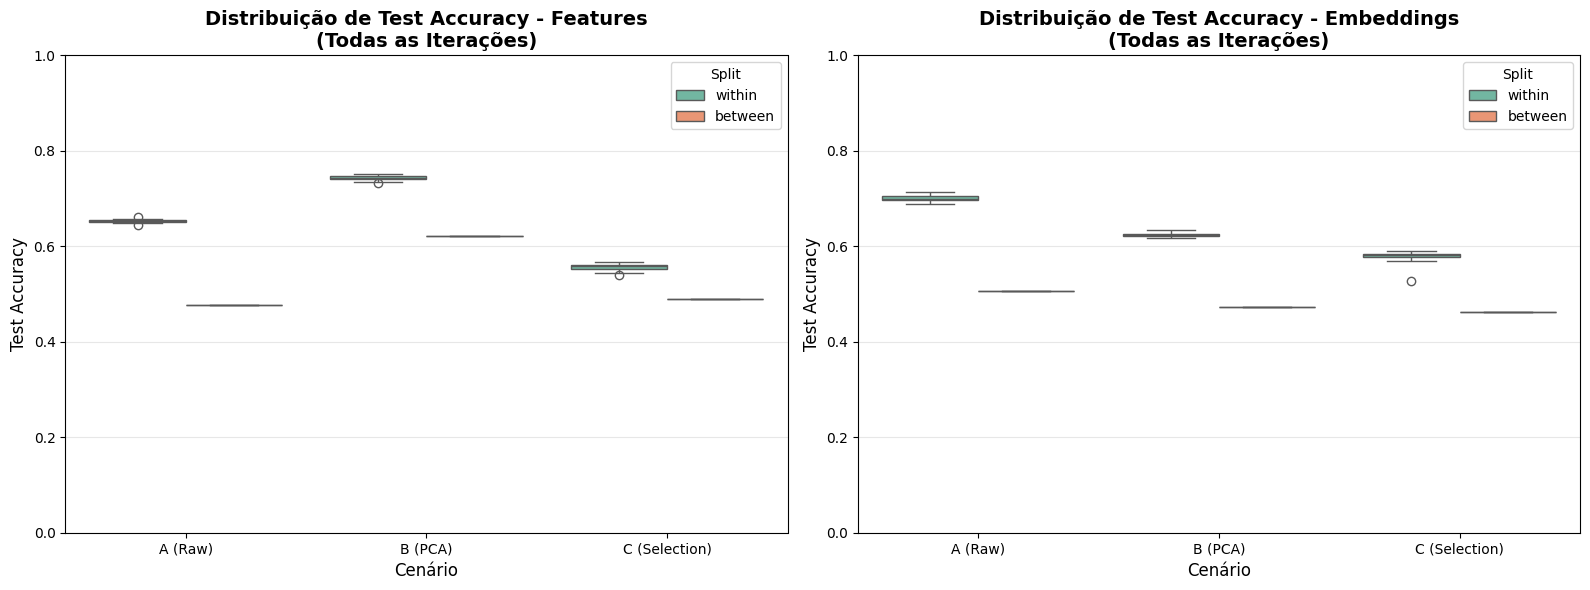

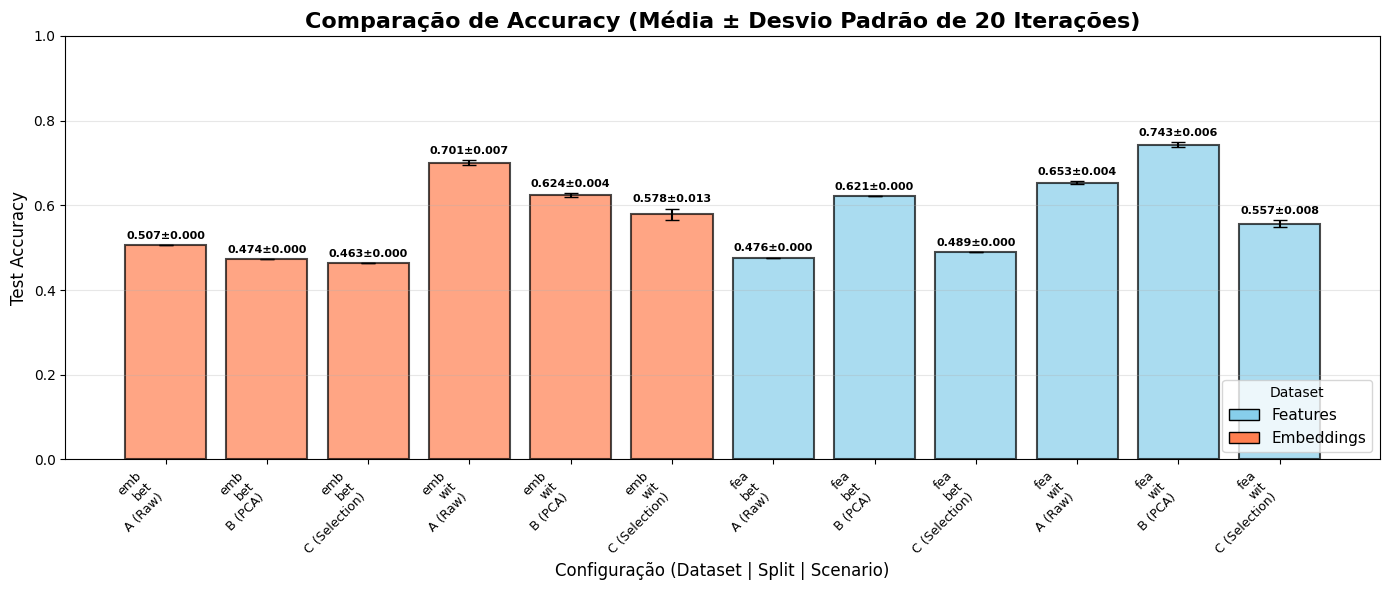

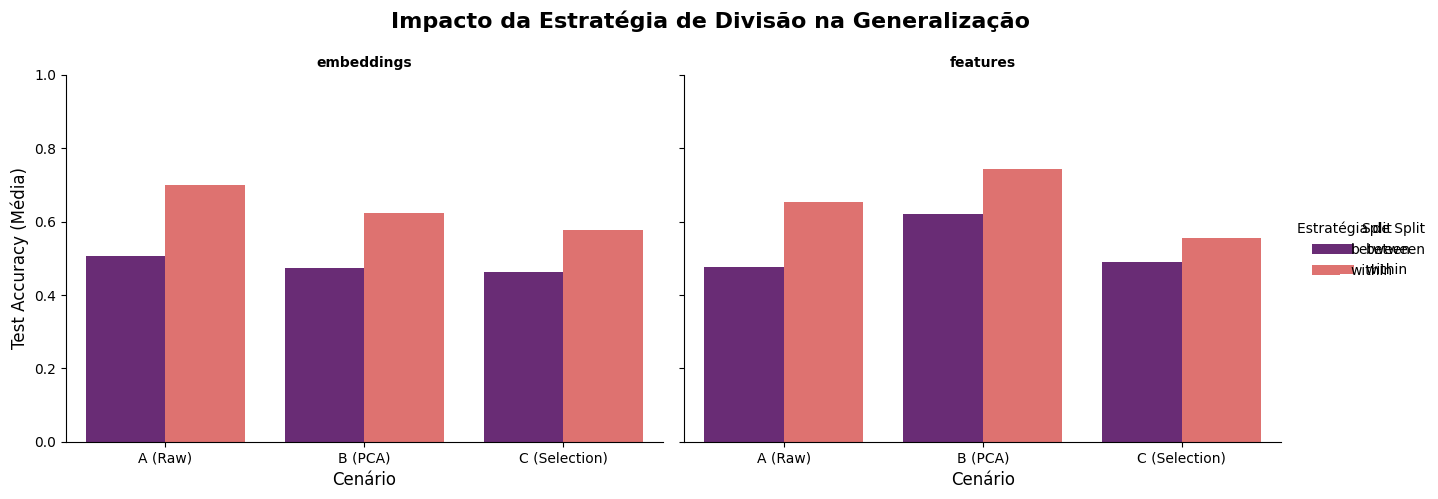

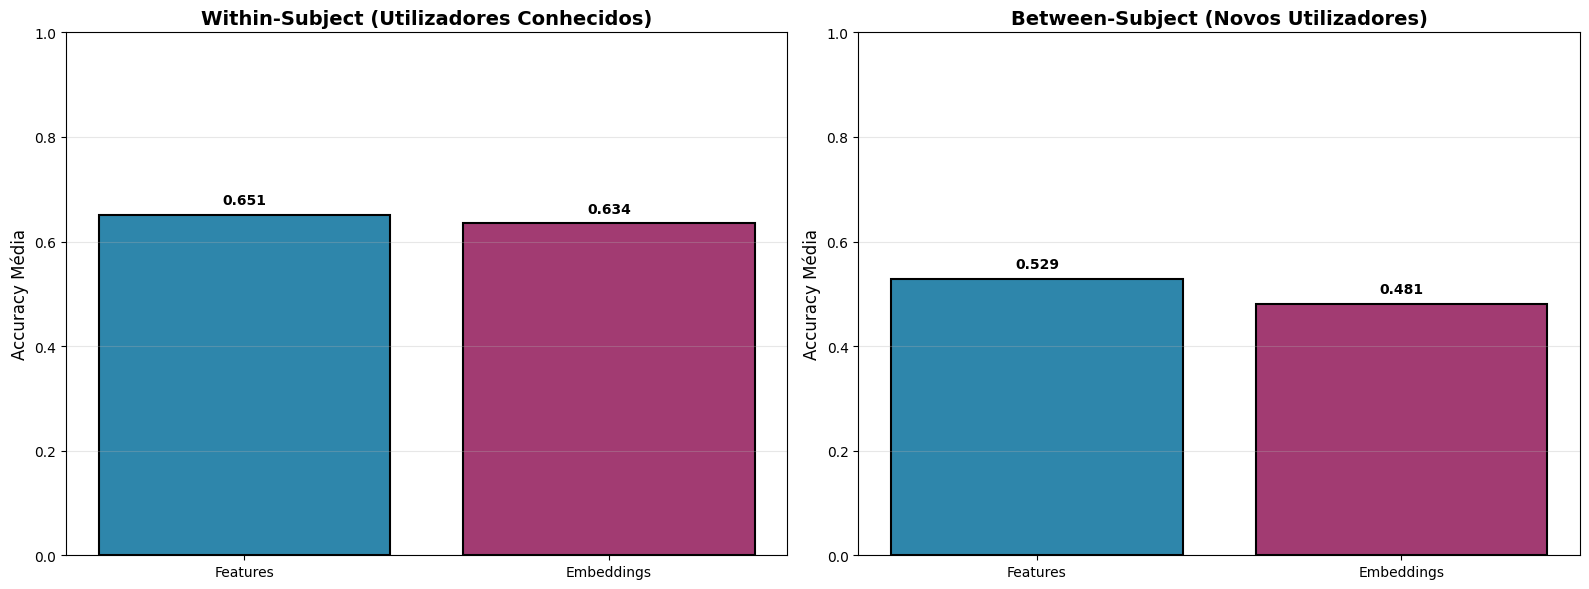

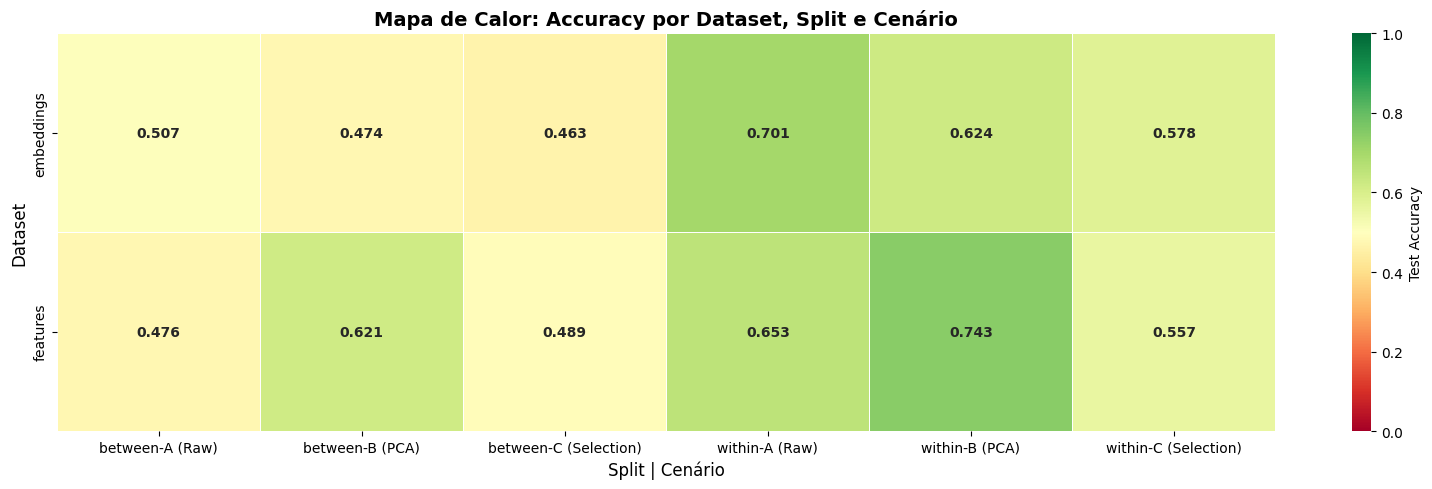

<Figure size 1200x600 with 0 Axes>

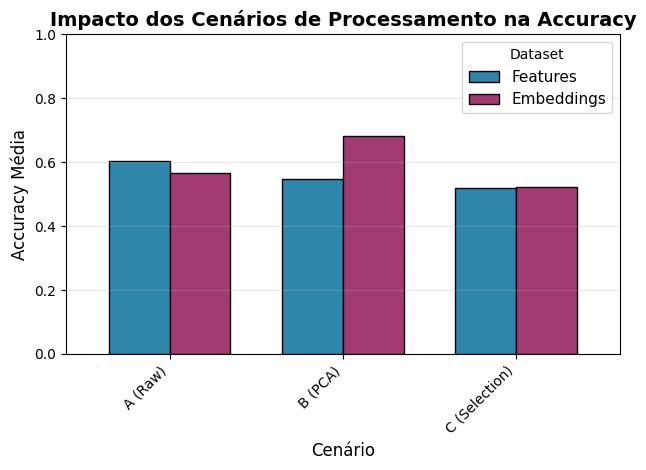

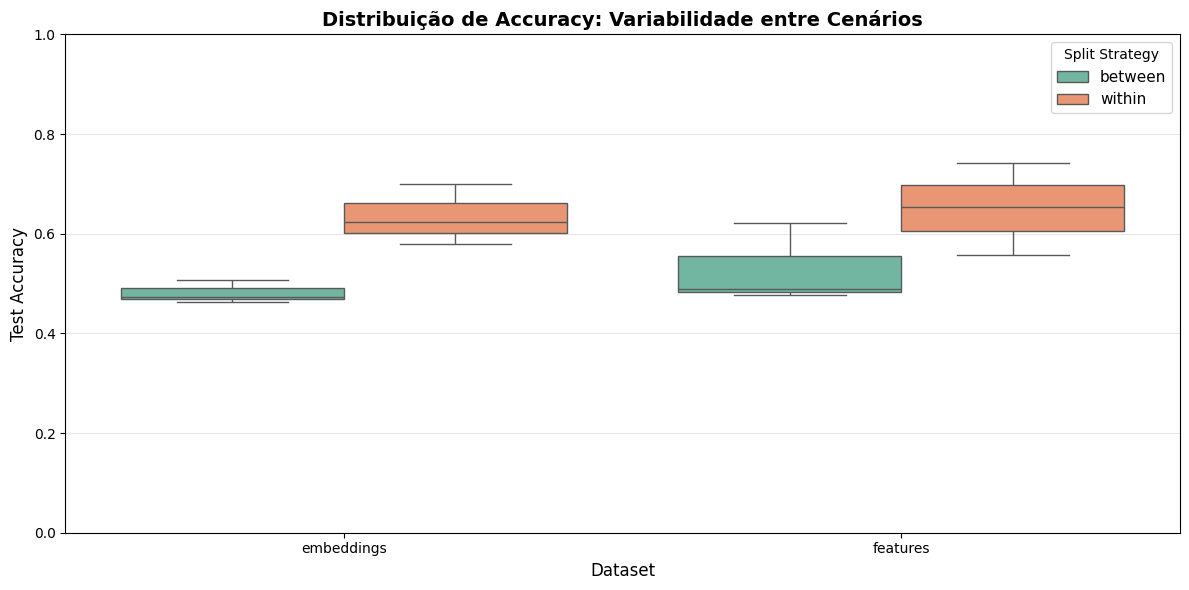


 Melhor Modelo: features_within_B (PCA)
Test Accuracy: 0.7428 (74.28%)
F1-Score: 0.7382


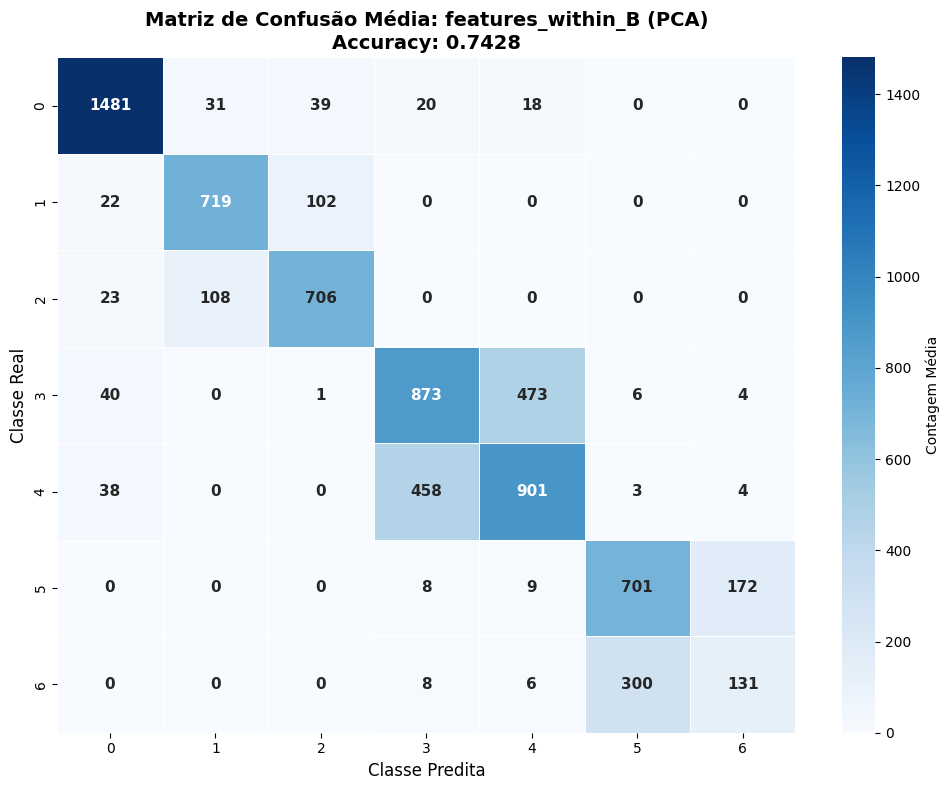

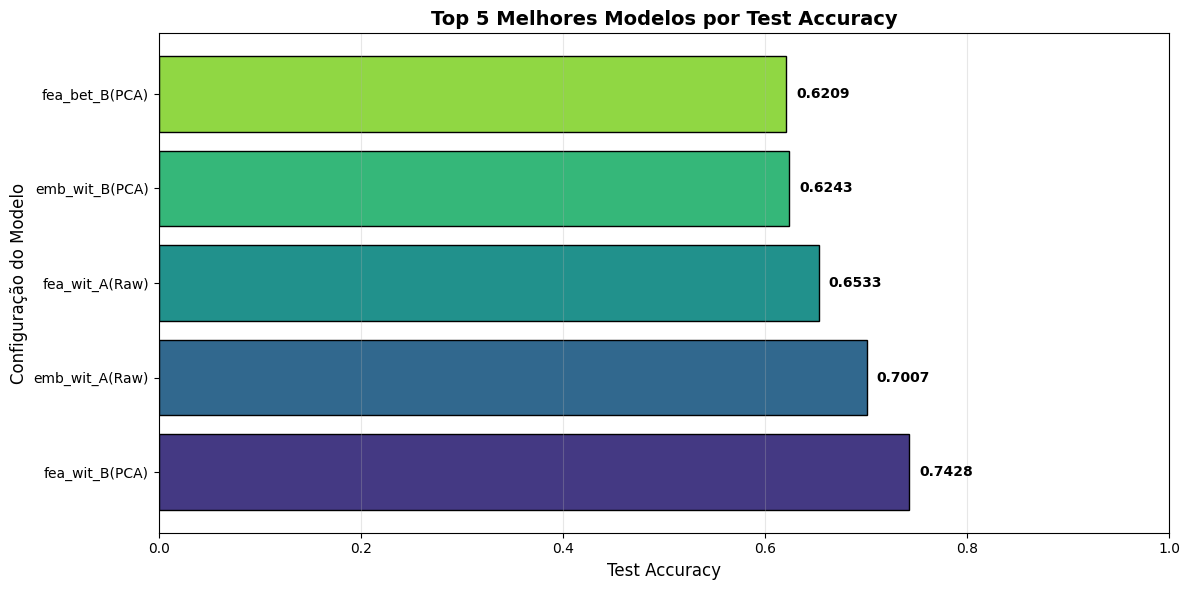


RESUMO ESTATÍSTICO FINAL

 Estatísticas Gerais:
Melhor Accuracy:  0.7428
Pior Accuracy:    0.4626
Accuracy Média:   0.5738
Desvio Padrão:    0.0952

 Por Dataset:

   FEATURES:
Média: 0.5898
Max:   0.7428
Min:   0.4764

   EMBEDDINGS:
Média: 0.5577
Max:   0.7007
Min:   0.4626

 Por Split:

   WITHIN:
Média: 0.6427
Max:   0.7428
Min:   0.5565

   BETWEEN:
Média: 0.5049
Max:   0.6209
Min:   0.4626


In [28]:
print("="*80)
print("5.2 - VISUALIZAÇÃO E ANÁLISE DE RESULTADOS")
print("="*80)

# GRÁFICO 1: Distribuição das Iterações com Boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
sns.boxplot(data=df_results_detail[df_results_detail['Dataset'] == 'features'], 
            x='Scenario', y='Test_Accuracy', hue='Split', ax=ax1, palette='Set2')
ax1.set_title('Distribuição de Test Accuracy - Features\n(Todas as Iterações)', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Cenário', fontsize=12)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_ylim(0.0, 1.0)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(title='Split', fontsize=10)

ax2 = axes[1]
sns.boxplot(data=df_results_detail[df_results_detail['Dataset'] == 'embeddings'], 
            x='Scenario', y='Test_Accuracy', hue='Split', ax=ax2, palette='Set2')
ax2.set_title('Distribuição de Test Accuracy - Embeddings\n(Todas as Iterações)', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Cenário', fontsize=12)
ax2.set_ylabel('Test Accuracy', fontsize=12)
ax2.set_ylim(0.0, 1.0)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(title='Split', fontsize=10)

plt.tight_layout()
plt.show()


# GRÁFICO 2: Comparação Geral - Barras com Média ± Desvio Padrão
plt.figure(figsize=(14, 6))

x_pos = np.arange(len(df_results))
colors = ['skyblue' if d == 'features' else 'coral' for d in df_results['Dataset']]

bars = plt.bar(x_pos, df_results['Test_Accuracy_mean'], 
               yerr=df_results['Test_Accuracy_std'],
               color=colors, alpha=0.7, capsize=5, edgecolor='black', linewidth=1.5)

plt.title(f'Comparação de Accuracy (Média ± Desvio Padrão de {N_ITERATIONS} Iterações)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Configuração (Dataset | Split | Scenario)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.ylim(0.0, 1.0)
plt.xticks(x_pos, 
           [f"{row['Dataset'][:3]}\n{row['Split'][:3]}\n{row['Scenario']}" 
            for _, row in df_results.iterrows()],
           rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', alpha=0.3)

for i, (bar, mean, std) in enumerate(zip(bars, df_results['Test_Accuracy_mean'], df_results['Test_Accuracy_std'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
             f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

legend_elements = [Patch(facecolor='skyblue', edgecolor='black', label='Features'),
                   Patch(facecolor='coral', edgecolor='black', label='Embeddings')]
plt.legend(handles=legend_elements, title='Dataset', fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()


# GRÁFICO 3: Impacto do Split (Within vs Between) - Média das Iterações
g = sns.catplot(
    data=df_results, kind="bar",
    x="Scenario", y="Test_Accuracy_mean", hue="Split", col="Dataset",
    palette="magma", height=5, aspect=1.2, legend=True
)
g.set_axis_labels("Cenário", "Test Accuracy (Média)", fontsize=12)
g.set_titles("{col_name}", fontsize=14, fontweight='bold')
g.set(ylim=(0, 1.0))
g.add_legend(title='Estratégia de Split')

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Impacto da Estratégia de Divisão na Generalização', 
               fontsize=16, fontweight='bold')
plt.show()


# GRÁFICO 4: Comparação Direta Features vs Embeddings por Split
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Within-Subject
df_within = df_results[df_results['Split'] == 'within']
axes[0].bar(
    x=['Features', 'Embeddings'],
    height=[
        df_within[df_within['Dataset']=='features']['Test_Accuracy_mean'].mean(),
        df_within[df_within['Dataset']=='embeddings']['Test_Accuracy_mean'].mean()
    ],
    color=['#2E86AB', '#A23B72'],
    edgecolor='black',
    linewidth=1.5
)
axes[0].set_title('Within-Subject (Utilizadores Conhecidos)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy Média', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

for i, (label, height) in enumerate(zip(['Features', 'Embeddings'], 
    [df_within[df_within['Dataset']=='features']['Test_Accuracy_mean'].mean(),
     df_within[df_within['Dataset']=='embeddings']['Test_Accuracy_mean'].mean()])):
    axes[0].text(i, height + 0.02, f'{height:.3f}', ha='center', fontweight='bold')

# Between-Subject
df_between = df_results[df_results['Split'] == 'between']
axes[1].bar(
    x=['Features', 'Embeddings'],
    height=[
        df_between[df_between['Dataset']=='features']['Test_Accuracy_mean'].mean(),
        df_between[df_between['Dataset']=='embeddings']['Test_Accuracy_mean'].mean()
    ],
    color=['#2E86AB', '#A23B72'],
    edgecolor='black',
    linewidth=1.5
)
axes[1].set_title('Between-Subject (Novos Utilizadores)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy Média', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

for i, (label, height) in enumerate(zip(['Features', 'Embeddings'], 
    [df_between[df_between['Dataset']=='features']['Test_Accuracy_mean'].mean(),
     df_between[df_between['Dataset']=='embeddings']['Test_Accuracy_mean'].mean()])):
    axes[1].text(i, height + 0.02, f'{height:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


# GRÁFICO 5: Heatmap de Resultados (Panorama Completo)
pivot_table = df_results.pivot_table(
    values='Test_Accuracy_mean', 
    index=['Dataset'], 
    columns=['Split', 'Scenario'],
    aggfunc='mean'
)

plt.figure(figsize=(16, 5))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, 
            linewidths=0.5, cbar_kws={'label': 'Test Accuracy'}, 
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})
plt.title('Mapa de Calor: Accuracy por Dataset, Split e Cenário', 
          fontsize=14, fontweight='bold')
plt.ylabel('Dataset', fontsize=12)
plt.xlabel('Split | Cenário', fontsize=12)
plt.tight_layout()
plt.show()



# GRÁFICO 6: Comparação de Cenários (A, B, C)
plt.figure(figsize=(12, 6))
scenario_comparison = df_results.groupby(['Scenario', 'Dataset'])['Test_Accuracy_mean'].mean().unstack()
scenario_comparison.plot(kind='bar', color=['#2E86AB', '#A23B72'], width=0.7, edgecolor='black')
plt.title('Impacto dos Cenários de Processamento na Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Cenário', fontsize=12)
plt.ylabel('Accuracy Média', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Dataset', labels=['Features', 'Embeddings'], fontsize=11)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



# GRÁFICO 7: Boxplot - Distribuição de Accuracy
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_results, x='Dataset', y='Test_Accuracy_mean', hue='Split', palette='Set2')
plt.title('Distribuição de Accuracy: Variabilidade entre Cenários', fontsize=14, fontweight='bold')
plt.xlabel('Dataset', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title='Split Strategy', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



# GRÁFICO 8: Matriz de Confusão do Melhor Modelo
best_model_idx = df_results['Test_Accuracy_mean'].idxmax()
best_row = df_results.loc[best_model_idx]
best_id = f"{best_row['Dataset']}_{best_row['Split']}_{best_row['Scenario']}"

print(f"\n Melhor Modelo: {best_id}")
print(f"Test Accuracy: {best_row['Test_Accuracy_mean']:.4f} ({best_row['Test_Accuracy_mean']*100:.2f}%)")
print(f"F1-Score: {best_row['F1_Score_mean']:.4f}")


cm_list = []
for iteration in range(1, N_ITERATIONS + 1):
    key = f"{best_id}_iter{iteration}"
    if key in confusion_matrices:
        cm_list.append(confusion_matrices[key])

if cm_list:
    cm_mean = np.mean(cm_list, axis=0).astype(int)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_mean, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
                cbar_kws={'label': 'Contagem Média'}, annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    plt.title(f'Matriz de Confusão Média: {best_id}\nAccuracy: {best_row["Test_Accuracy_mean"]:.4f}', 
              fontsize=14, fontweight='bold')
    plt.ylabel('Classe Real', fontsize=12)
    plt.xlabel('Classe Predita', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Aviso: Matriz de confusão não encontrada para o melhor modelo.")



# GRÁFICO 9: Top 5 Modelos - Ranking
top_5 = df_results.nlargest(5, 'Test_Accuracy_mean').copy()
top_5['Model_ID'] = (top_5['Dataset'].str[:3] + '_' + 
                      top_5['Split'].str[:3] + '_' + 
                      top_5['Scenario'].str.replace(' ', ''))

plt.figure(figsize=(12, 6))
bars = plt.barh(top_5['Model_ID'], top_5['Test_Accuracy_mean'], 
                color=sns.color_palette('viridis', 5), edgecolor='black')


for i, (bar, acc) in enumerate(zip(bars, top_5['Test_Accuracy_mean'])):
    plt.text(acc + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{acc:.4f}', va='center', fontweight='bold', fontsize=10)

plt.title('Top 5 Melhores Modelos por Test Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Test Accuracy', fontsize=12)
plt.ylabel('Configuração do Modelo', fontsize=12)
plt.xlim(0, 1.0)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()





# RESUMO
print("\n" + "="*80)
print("RESUMO ESTATÍSTICO FINAL")
print("="*80)

print("\n Estatísticas Gerais:")
print(f"Melhor Accuracy:  {df_results['Test_Accuracy_mean'].max():.4f}")
print(f"Pior Accuracy:    {df_results['Test_Accuracy_mean'].min():.4f}")
print(f"Accuracy Média:   {df_results['Test_Accuracy_mean'].mean():.4f}")
print(f"Desvio Padrão:    {df_results['Test_Accuracy_mean'].std():.4f}")

print("\n Por Dataset:")
for dataset in ['features', 'embeddings']:
    subset = df_results[df_results['Dataset'] == dataset]
    print(f"\n   {dataset.upper()}:")
    print(f"Média: {subset['Test_Accuracy_mean'].mean():.4f}")
    print(f"Max:   {subset['Test_Accuracy_mean'].max():.4f}")
    print(f"Min:   {subset['Test_Accuracy_mean'].min():.4f}")

print("\n Por Split:")
for split in ['within', 'between']:
    subset = df_results[df_results['Split'] == split]
    print(f"\n   {split.upper()}:")
    print(f"Média: {subset['Test_Accuracy_mean'].mean():.4f}")
    print(f"Max:   {subset['Test_Accuracy_mean'].max():.4f}")
    print(f"Min:   {subset['Test_Accuracy_mean'].min():.4f}")



### 5.3 Teste de Hipóteses

In [29]:

print("\n" + "="*80)
print("ANÁLISE ESTATÍSTICA COMPLETA")
print("="*80)

# 1. Separar resultados por estratégia de Split
mask_between = df_results['Split'] == 'between'
mask_within = df_results['Split'] == 'within'


# ANÁLISE A: GENERALIZAÇÃO (Between-Subjects - Novos Utilizadores)
print("\n TESTE A: Capacidade de Generalização (Between-Subjects)")
print("-" * 80)

acc_feat_bet = df_results[(df_results['Dataset']=='features') & mask_between]['Test_Accuracy_mean'].values
acc_emb_bet = df_results[(df_results['Dataset']=='embeddings') & mask_between]['Test_Accuracy_mean'].values

print(f"Estatísticas Descritivas:")
print(f"Features    → Média: {acc_feat_bet.mean():.4f} | Std: {acc_feat_bet.std():.4f}")
print(f"Embeddings  → Média: {acc_emb_bet.mean():.4f} | Std: {acc_emb_bet.std():.4f}")
print(f"Diferença   → {abs(acc_feat_bet.mean() - acc_emb_bet.mean()):.4f}")

# Teste T Emparelhado (porque os mesmos cenários são testados)
t_stat_bet, p_val_bet = ttest_rel(acc_feat_bet, acc_emb_bet)
print(f"\n Teste T Emparelhado:")
print(f"t-statistic: {t_stat_bet:.4f}")
print(f"p-value: {p_val_bet:.4f}")

print(f"\n INTERPRETAÇÃO (α = 0.05):")
if p_val_bet < 0.05:
    winner = "Features" if acc_feat_bet.mean() > acc_emb_bet.mean() else "Embeddings"
    print(f"Diferença significativa detetada")
    print(f"Vencedor: {winner} , Conclusão: O modelo com {winner} é estatisticamente superior, para reconhecer atividades de pessoas NUNCA vistas antes ")
else:
    print(f"Sem diferença estatística significativa. Conclusão: Features e Embeddings têm desempenho equivalente na generalização para novos utilizadores.")

# ANÁLISE B: ADAPTAÇÃO (Within-Subject - Utilizadores Conhecidos)
print("\n" + "-" * 80)
print("TESTE B: Capacidade de Adaptação (Within-Subject)")
print("-" * 80)

acc_feat_wit = df_results[(df_results['Dataset']=='features') & mask_within]['Test_Accuracy_mean'].values
acc_emb_wit = df_results[(df_results['Dataset']=='embeddings') & mask_within]['Test_Accuracy_mean'].values

print(f"Estatísticas Descritivas:")
print(f"Features    → Média: {acc_feat_wit.mean():.4f} | Std: {acc_feat_wit.std():.4f}")
print(f"Embeddings  → Média: {acc_emb_wit.mean():.4f} | Std: {acc_emb_wit.std():.4f}")
print(f"Diferença   → {abs(acc_feat_wit.mean() - acc_emb_wit.mean()):.4f}")

t_stat_wit, p_val_wit = ttest_rel(acc_feat_wit, acc_emb_wit)
print(f"\n Teste T Emparelhado:")
print(f"t-statistic: {t_stat_wit:.4f}")
print(f"p-value: {p_val_wit:.4f}")

print(f"\n INTERPRETAÇÃO (α = 0.05):")
if p_val_wit < 0.05:
    winner = "Features" if acc_feat_wit.mean() > acc_emb_wit.mean() else "Embeddings"
    print(f"Diferença significativa detetada!")
    print(f"Vencedor: {winner}, Conclusão: O modelo com {winner} adapta-se melhor aos padrões individuais dos utilizadores vistos no treino.")
else:
    print(f"Sem diferença estatística significativa. Conclusão: Ambas as abordagens têm desempenho similar quando o modelo já conhece os utilizadores.")


# ANÁLISE C: Comparação Within vs Between (Overfitting Check)
print("\n" + "="*80)
print("TESTE C: Análise de Overfitting (Within vs Between)")
print("="*80)

gap_features = acc_feat_wit.mean() - acc_feat_bet.mean()
gap_embeddings = acc_emb_wit.mean() - acc_emb_bet.mean()

print(f"Gap de Generalização (Within - Between):")
print(f"Features:   {gap_features:.4f} ({gap_features*100:.2f}% diferença)")
print(f"Embeddings: {gap_embeddings:.4f} ({gap_embeddings*100:.2f}% diferença)")

print(f"\n INTERPRETAÇÃO:")
if gap_features > 0.15:  
    print(f"Features mostram forte overfitting aos utilizadores de treino (Accuracy cai {gap_features*100:.1f}% em dados novos)")
elif gap_embeddings > 0.15:
    print(f"Embeddings mostram forte overfitting aos utilizadores de treino (Accuracy cai {gap_embeddings*100:.1f}% em dados novos)")
else:
    print(f"Ambos os modelos generalizam razoavelmente bem. Gap típico: 5-15% entre Within e Between é esperado.")




print("\n" + "="*80)
print("Resumo")
print("="*80)

best_between = "Features" if acc_feat_bet.mean() > acc_emb_bet.mean() else "Embeddings"
best_within = "Features" if acc_feat_wit.mean() > acc_emb_wit.mean() else "Embeddings"

print(f"Melhor para Generalização (Novos Utilizadores): {best_between}")
print(f"Melhor para Adaptação (Utilizadores Conhecidos): {best_within}")

if best_between == best_within:
    print(f"\n RECOMENDAÇÃO: Use {best_between} (consistentemente melhor)")
else:
    print(f"\n RECOMENDAÇÃO: A escolha depende da aplicação:")
    print(f"    • Sistema universal (novos utilizadores) → {best_between}")
    print(f"    • Sistema personalizado (mesmos utilizadores) → {best_within}")

print("="*80)



ANÁLISE ESTATÍSTICA COMPLETA

 TESTE A: Capacidade de Generalização (Between-Subjects)
--------------------------------------------------------------------------------
Estatísticas Descritivas:
Features    → Média: 0.5288 | Std: 0.0653
Embeddings  → Média: 0.4809 | Std: 0.0187
Diferença   → 0.0479

 Teste T Emparelhado:
t-statistic: 0.9152
p-value: 0.4567

 INTERPRETAÇÃO (α = 0.05):
Sem diferença estatística significativa. Conclusão: Features e Embeddings têm desempenho equivalente na generalização para novos utilizadores.

--------------------------------------------------------------------------------
TESTE B: Capacidade de Adaptação (Within-Subject)
--------------------------------------------------------------------------------
Estatísticas Descritivas:
Features    → Média: 0.6509 | Std: 0.0761
Embeddings  → Média: 0.6345 | Std: 0.0504
Diferença   → 0.0164

 Teste T Emparelhado:
t-statistic: 0.3181
p-value: 0.7806

 INTERPRETAÇÃO (α = 0.05):
Sem diferença estatística significativa

## 6. Deployment

Melhor Modelo: features | within | B (PCA) | k=3
Labels únicos no treino: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Shape X_transformed: (29694, 48)
Shape y_full: 29694
Distribuição de classes no treino: {1: 6372, 2: 3379, 3: 3352, 4: 5600, 5: 5632, 6: 3570, 7: 1789}
Classes do modelo: [1 2 3 4 5 6 7]
Acurácia nas primeiras 100 amostras de treino: 100.00%
Distribuição das predições: {np.int64(1): 24, np.int64(2): 16, np.int64(3): 11, np.int64(4): 18, np.int64(5): 15, np.int64(6): 12, np.int64(7): 4}
✓ Modelo guardado em 'best_model_artifacts.pkl'

DIAGNÓSTICO DO SISTEMA

[DIAGNÓSTICO 1] Distribuição de Predições
--------------------------------------------------------------------------------

Total de testes: 35

Distribuição das predições:
  Atividade 1 (Stand): 5 (14.3%)
  Atividade 2 (Sit): 5 (14.3%)
  Atividade 3 (Sit and Talk): 5 (14.3%)
  Atividade 4 (Walk): 5 (14.3%)
  Atividade 5 (Walk and Talk): 5 (14.3%)
  Atividade 6 (Climb S

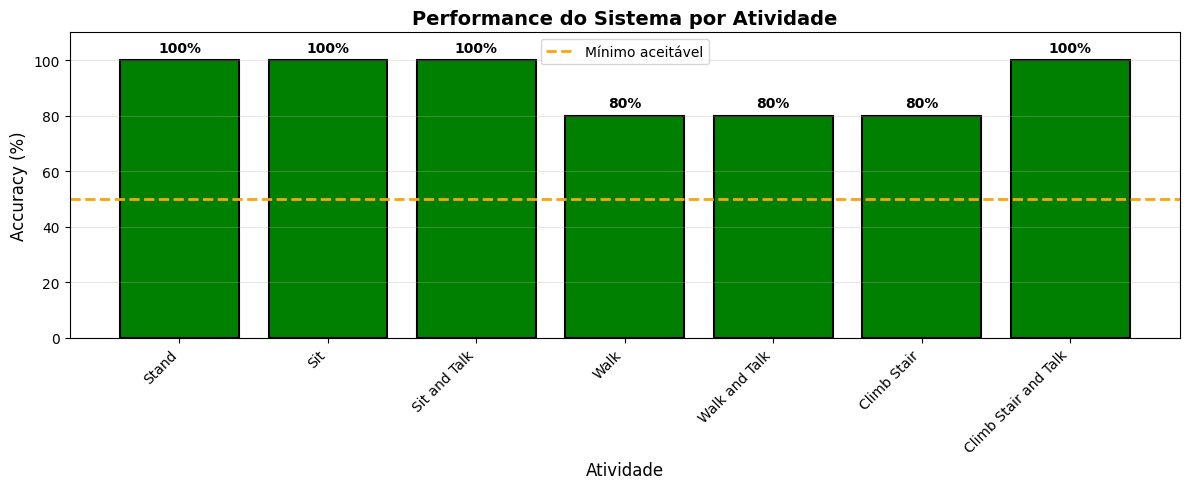


 Sistema funcionando adequadamente!


In [ ]:
def save_best_model_artifacts():    
    best_idx = df_results['Test_Accuracy_mean'].idxmax()
    best_config = df_results.loc[best_idx]
    
    dataset_type = best_config['Dataset']
    scenario_name = best_config['Scenario']
    split_name = best_config['Split']
    
    detail_subset = df_results_detail[
        (df_results_detail['Dataset'] == dataset_type) & 
        (df_results_detail['Split'] == split_name) & 
        (df_results_detail['Scenario'] == scenario_name)
    ]
    best_k = int(detail_subset['Best_k'].mode()[0]) 
    
    print(f"Melhor Modelo: {dataset_type} | {split_name} | {scenario_name} | k={best_k}")

    data_source = master_data[dataset_type][best_config['Split']]['A (Raw)']
    
    if isinstance(data_source['X_train'], pd.DataFrame):
        X_full = pd.concat([data_source['X_train'], data_source['X_val']], ignore_index=True)
        y_full = pd.concat([data_source['y_train'], data_source['y_val']], ignore_index=True)
    else:
        X_full = pd.DataFrame(np.vstack([data_source['X_train'], data_source['X_val']]))
        y_full = np.concatenate([data_source['y_train'], data_source['y_val']])

    artifacts = {
        'config': {
            'dataset_type': dataset_type,
            'scenario': scenario_name,
            'best_k': best_k,
            'feature_names': X_full.columns.tolist()
        }
    }

    X_transformed = X_full.copy()
    
    if scenario_name != 'A (Raw)':
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_transformed)
        X_transformed = pd.DataFrame(X_scaled, columns=[f"scaled_{col}" for col in X_transformed.columns])
        artifacts['scaler'] = scaler

    if scenario_name == 'B (PCA)':
        pca = PCA(n_components=0.90)
        X_pca = pca.fit_transform(X_transformed)
        X_transformed = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
        artifacts['pca'] = pca
        
    elif scenario_name == 'C (Selection)':
        selector = SelectKBest(score_func=f_classif, k=min(15, X_transformed.shape[1]))
        X_selected = selector.fit_transform(X_transformed, y_full)
        selected_cols = X_transformed.columns[selector.get_support()].tolist()
        X_transformed = pd.DataFrame(X_selected, columns=selected_cols)
        artifacts['selector'] = selector

    artifacts['config']['final_feature_names'] = X_transformed.columns.tolist()

    # DEBUG: Verificar labels únicos antes do treino
    unique_labels = sorted(y_full.unique() if hasattr(y_full, 'unique') else np.unique(y_full))
    print(f"Labels únicos no treino: {unique_labels}")
    print(f"Shape X_transformed: {X_transformed.shape}")
    print(f"Shape y_full: {len(y_full)}")
    
    class_distribution = Counter(y_full)
    print(f"Distribuição de classes no treino: {dict(sorted(class_distribution.items()))}")
    
    final_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
    final_model.fit(X_transformed, y_full)
    artifacts['model'] = final_model
    artifacts['label_mapping'] = unique_labels
    
    print(f"Classes do modelo: {final_model.classes_}")
    
    # TESTE: Verificar se o modelo consegue prever corretamente nos dados de treino
    sample_predictions = final_model.predict(X_transformed[:100])
    y_full_array = y_full.values if hasattr(y_full, 'values') else y_full
    sample_accuracy = (sample_predictions == y_full_array[:100]).mean()
    print(f"Accuracy nas primeiras 100 amostras de treino: {sample_accuracy:.2%}")
    pred_distribution = Counter(sample_predictions)
    print(f"Distribuição das predições: {dict(sorted(pred_distribution.items()))}")

    with open('best_model_artifacts.pkl', 'wb') as f:
        pickle.dump(artifacts, f)
    
    print("✓ Modelo guardado em 'best_model_artifacts.pkl'")

save_best_model_artifacts()


# 2. FUNÇÃO DE CLASSIFICAÇÃO 
# Cache global para modelos
_cached_artifacts = None
_cached_embedding_model = None

def classify_activity(window_data, artifacts_path='best_model_artifacts.pkl'):
    global _cached_artifacts, _cached_embedding_model
    
    if _cached_artifacts is None:
        with open(artifacts_path, 'rb') as f:
            _cached_artifacts = pickle.load(f)
    
    artifacts = _cached_artifacts
    config = artifacts['config']
    model = artifacts['model']
    
    if config['dataset_type'] == 'embeddings':
        if _cached_embedding_model is None:
            _cached_embedding_model = load_model()
        
        feature_encoder, device = _cached_embedding_model
        
        acc_data = window_data[:, :3]
        INPUT_FS = 50.0  
        acc_resampled = resample_segment(acc_data, INPUT_FS, target_fs=30.0, target_duration=5.0)
        
        acc_transposed = acc_resampled.T  
        
        X_tensor = torch.tensor(acc_transposed, dtype=torch.float32).unsqueeze(0).to(device)
        
        with torch.no_grad():
            emb = feature_encoder(X_tensor)
        
        emb_array = emb.cpu().numpy().squeeze()
        if emb_array.ndim > 1:
            emb_array = emb_array.flatten()
        
        n_emb = len(emb_array)
        X_processed = pd.DataFrame([emb_array], columns=[f"emb_{i}" for i in range(n_emb)])
        
    else:
        sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z']
        df_window = pd.DataFrame(window_data, columns=sensor_cols)
        features_dict = extract_multivariate_features(df_window)
        X_processed = pd.DataFrame([features_dict])
        X_processed = X_processed.reindex(columns=config['feature_names'], fill_value=0)
        
        X_processed = X_processed.fillna(0)
        X_processed = X_processed.replace([np.inf, -np.inf], 0)

    if 'scaler' in artifacts:
        X_scaled = artifacts['scaler'].transform(X_processed)
        X_processed = pd.DataFrame(X_scaled, columns=[f"scaled_{col}" for col in X_processed.columns])
        X_processed = X_processed.fillna(0)
        X_processed = X_processed.replace([np.inf, -np.inf], 0)
    
    if 'pca' in artifacts:
        X_pca = artifacts['pca'].transform(X_processed)
        X_processed = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
    elif 'selector' in artifacts:
        X_selected = artifacts['selector'].transform(X_processed)
        X_processed = pd.DataFrame(X_selected, columns=config['final_feature_names'])

    X_processed = X_processed.reindex(columns=config['final_feature_names'], fill_value=0)
    
    X_processed = X_processed.fillna(0)
    X_processed = X_processed.replace([np.inf, -np.inf], 0)
    
    pred_idx = model.predict(X_processed)[0]
    
    activity_id = int(pred_idx)
    
    distances, neighbor_indices = model.kneighbors(X_processed)
    
    if hasattr(model, '_y'):
        neighbor_labels = model._y[neighbor_indices[0]]
    else:
        neighbor_labels = [activity_id] * len(neighbor_indices[0])
    
    confidence = (neighbor_labels == activity_id).sum() / len(neighbor_labels)
    
    activity_map = {
        1: "Stand", 2: "Sit", 3: "Sit and Talk", 4: "Walk", 
        5: "Walk and Talk", 6: "Climb Stair", 7: "Climb Stair and Talk"
    }
    
    return {
        'activity_id': activity_id,
        'activity_name': activity_map.get(activity_id, "Unknown"),
        'confidence': round(float(confidence), 4)
    }


# ====================================================================
# 3. DIAGNÓSTICO E TESTES
# ====================================================================

print("\n" + "="*80)
print("DIAGNÓSTICO DO SISTEMA")
print("="*80)

if 'df' not in globals():
    print("Dataset 'df' não disponível.")
else:
    cols_sensors = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z']
    activity_map = {
        1: "Stand", 2: "Sit", 3: "Sit and Talk", 4: "Walk", 
        5: "Walk and Talk", 6: "Climb Stair", 7: "Climb Stair and Talk"
    }
    
    # ----------------------------------------------------------------
    # DIAGNÓSTICO 1: Verificar distribuição de predictions
    # ----------------------------------------------------------------
    print("\n[DIAGNÓSTICO 1] Distribuição de Predictions")
    print("-" * 80)
    
    all_predictions = []
    all_true_labels = []
    
    for activity_id in activity_map.keys():
        samples = df[df['activity'] == activity_id]
        if len(samples) < 256:
            continue
        
        for i in range(min(5, len(samples) // 256)):
            start_idx = i * 256
            window = samples.iloc[start_idx:start_idx+256][cols_sensors].values
            
            result = classify_activity(window)
            all_predictions.append(result['activity_id'])
            all_true_labels.append(activity_id)
    
    pred_counts = Counter(all_predictions)
    
    print(f"\nTotal de testes: {len(all_predictions)}")
    print("\nDistribuição das predições:")
    for act_id, count in sorted(pred_counts.items()):
        pct = count / len(all_predictions) * 100
        print(f"  Atividade {act_id} ({activity_map[act_id]}): {count} ({pct:.1f}%)")
    
    most_common = pred_counts.most_common(1)[0]
    if most_common[1] > len(all_predictions) * 0.8:
        print(f"\n PROBLEMA DETETADO: Modelo prevê '{activity_map[most_common[0]]}' em {most_common[1]/len(all_predictions)*100:.1f}% dos casos!")
        print("   Possíveis causas:")
        print("   1. Features estão todas similares (problema na extração)")
        print("   2. Modelo não foi treinado corretamente")
        print("   3. Normalização está a colapsar as features")
    
    
    # ----------------------------------------------------------------
    # DIAGNÓSTICO 2: Verificar variabilidade das features
    # ----------------------------------------------------------------
    print("\n[DIAGNÓSTICO 2] Análise de Features Extraídas")
    print("-" * 80)
    
    with open('best_model_artifacts.pkl', 'rb') as f:
        saved_artifacts = pickle.load(f)
    
    print(f"\nConfigurações do modelo salvo:")
    print(f"  Dataset type: {saved_artifacts['config']['dataset_type']}")
    print(f"  Scenario: {saved_artifacts['config']['scenario']}")
    print(f"  Best k: {saved_artifacts['config']['best_k']}")
    print(f"  Classes do modelo: {saved_artifacts['model'].classes_}")
    print(f"  Número de features: {len(saved_artifacts['config']['final_feature_names'])}")
    
    test_activities = [1, 4, 6]  
    features_by_activity = {}
    
    for act_id in test_activities:
        samples = df[df['activity'] == act_id]
        if len(samples) < 256:
            continue
        
        window = samples.iloc[0:256][cols_sensors].values
        sensor_cols_names = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z']
        df_window = pd.DataFrame(window, columns=sensor_cols_names)
        features_dict = extract_multivariate_features(df_window)
        
        features_by_activity[act_id] = pd.Series(features_dict)
    
    if len(features_by_activity) >= 2:
        feat_names = list(features_by_activity[test_activities[0]].index)[:10] 
        
        print(f"\nPrimeiras 10 features para diferentes atividades:")
        comparison_df = pd.DataFrame({
            activity_map[act_id]: features_by_activity[act_id][feat_names] 
            for act_id in test_activities if act_id in features_by_activity
        })
        print(comparison_df.to_string())
        
        std_values = comparison_df.std(axis=1)
        if (std_values < 0.01).sum() > len(std_values) * 0.5:
            print("\n PROBLEMA: Mais de 50% das features têm desvio padrão < 0.01")
            print("   Features não estão a diferenciar as atividades!")
        else:
            print("\n Features mostram variabilidade entre atividades")
    
    
    # ----------------------------------------------------------------
    # DIAGNÓSTICO 3: Verificar dados de entrada
    # ----------------------------------------------------------------
    print("\n[DIAGNÓSTICO 3] Qualidade dos Dados de Entrada")
    print("-" * 80)
    
    for act_id in [1, 4, 6]:
        samples = df[df['activity'] == act_id]
        if len(samples) < 256:
            continue
        
        window = samples.iloc[0:256][cols_sensors].values
        
        print(f"\nAtividade {act_id} ({activity_map[act_id]}):")
        print(f"  Shape: {window.shape}")
        print(f"  Range acc_x: [{window[:, 0].min():.2f}, {window[:, 0].max():.2f}]")
        print(f"  Std acc_x: {window[:, 0].std():.2f}")
        print(f"  NaNs: {np.isnan(window).sum()}")
    
    
    # ----------------------------------------------------------------
    # DIAGNÓSTICO 4: Testar prediction direta do modelo
    # ----------------------------------------------------------------
    print("\n[DIAGNÓSTICO 4] Teste Direto do Modelo (sem pipeline)")
    print("-" * 80)
    
    with open('best_model_artifacts.pkl', 'rb') as f:
        test_artifacts = pickle.load(f)
    
    test_model = test_artifacts['model']
    
    print("\nTeste com amostras reais (acesso direto ao modelo):")
    for act_id in [1, 4, 6]:
        samples = df[df['activity'] == act_id]
        if len(samples) < 256:
            continue
        
        window = samples.iloc[0:256][cols_sensors].values
        sensor_cols_names = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z']
        df_window = pd.DataFrame(window, columns=sensor_cols_names)
        features_dict = extract_multivariate_features(df_window)
        X_test_sample = pd.DataFrame([features_dict])
        X_test_sample = X_test_sample.reindex(columns=test_artifacts['config']['feature_names'], fill_value=0)
        
        if test_artifacts['config']['scenario'] != 'A (Raw)':
            X_test_sample = test_artifacts['scaler'].transform(X_test_sample)
        
        if 'pca' in test_artifacts:
            X_test_sample = test_artifacts['pca'].transform(X_test_sample)
        elif 'selector' in test_artifacts:
            X_test_sample = test_artifacts['selector'].transform(X_test_sample)
        
        pred_direct = test_model.predict(X_test_sample)[0]
        proba = test_model.predict_proba(X_test_sample)[0] if hasattr(test_model, 'predict_proba') else None
        
        print(f"\n  Atividade real: {act_id} ({activity_map[act_id]})")
        print(f"  Predição do modelo: {pred_direct}")
        print(f"  Classes do modelo: {test_model.classes_}")
        if proba is not None:
            print(f"  Probabilidades: {dict(zip(test_model.classes_, proba))}")
    
    # ----------------------------------------------------------------
    # DIAGNÓSTICO 5: Testar modelo com dados sintéticos
    # ----------------------------------------------------------------
    print("\n[DIAGNÓSTICO 5] Teste com Dados Sintéticos Controlados")
    print("-" * 80)
    
    synthetic_patterns = {
        1: np.ones((256, 9)) * 0.1,      
        4: np.ones((256, 9)) * 5.0,      
        6: np.ones((256, 9)) * 10.0     
    }
    
    print("\nTestando com padrões sintéticos distintos:")
    for act_id, pattern in synthetic_patterns.items():
        result = classify_activity(pattern)
        match = "✓" if result['activity_id'] == act_id else "✗"
        print(f"  {match} Esperado: {activity_map[act_id]} | Previsto: {result['activity_name']} (conf: {result['confidence']:.3f})")
    

    print("\n" + "="*80)
    print("TESTE COMPLETO DE VALIDAÇÃO")
    print("="*80)
    
    test_results_detailed = []
    
    for activity_id, activity_name in activity_map.items():
        print(f"\n[Atividade {activity_id}: {activity_name}]")
        
        samples = df[df['activity'] == activity_id]
        
        if len(samples) < 256:
            print(f"   Dados insuficientes")
            continue
        
        n_tests = min(10, len(samples) // 256)
        predictions = []
        confidences = []
        
        for i in range(n_tests):
            start_idx = i * 256
            window = samples.iloc[start_idx:start_idx+256][cols_sensors].values
            
            result = classify_activity(window)
            predictions.append(result['activity_id'])
            confidences.append(result['confidence'])
        
        pred_counter = Counter(predictions)
        correct = pred_counter[activity_id]
        accuracy = (correct / n_tests * 100)
        
        test_results_detailed.append({
            'activity_id': activity_id,
            'activity_name': activity_name,
            'correct': correct,
            'total': n_tests,
            'accuracy': accuracy,
            'most_predicted': pred_counter.most_common(1)[0][0],
            'avg_conf': np.mean(confidences)
        })
        
        print(f"  Accuracy: {accuracy:.1f}% ({correct}/{n_tests})")
        print(f"  Predições: {dict(pred_counter)}")
        print(f"  Confiança média: {np.mean(confidences):.3f}")
        
        if correct == 0:
            print(f"   ZERO acertos! Modelo sempre prevê: {activity_map[pred_counter.most_common(1)[0][0]]}")
    
    if test_results_detailed:
        df_test_results = pd.DataFrame(test_results_detailed)
        
        print("\n" + "="*80)
        print("RESUMO FINAL")
        print("="*80)
        print(df_test_results[['activity_name', 'accuracy', 'avg_conf']].to_string(index=False))
        
        overall_acc = df_test_results['correct'].sum() / df_test_results['total'].sum() * 100
        print(f"\nAccuracy Global: {overall_acc:.2f}%")
        
        plt.figure(figsize=(12, 5))
        bars = plt.bar(df_test_results['activity_name'], df_test_results['accuracy'],
                       color=['green' if x >= 50 else 'red' for x in df_test_results['accuracy']],
                       edgecolor='black', linewidth=1.5)
        
        for bar, acc in zip(bars, df_test_results['accuracy']):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 2,
                    f'{acc:.0f}%', ha='center', va='bottom', fontweight='bold')
        
        plt.axhline(y=50, color='orange', linestyle='--', linewidth=2, label='Mínimo aceitável')
        plt.title('Performance do Sistema por Atividade', fontsize=14, fontweight='bold')
        plt.xlabel('Atividade', fontsize=12)
        plt.ylabel('Accuracy (%)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.ylim(0, 110)
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        if overall_acc < 30:
            print("\n" + "="*80)
            print(" DIAGNÓSTICO: Sistema com performance muito baixa!")
            print("="*80)
            print("\nPossíveis soluções:")
            print("1. Verificar se o melhor modelo foi corretamente identificado")
            print("2. Re-treinar com window_size e stride corretos (devem coincidir com deployment)")
            print("3. Verificar se extração de features está consistente")
            print("4. Considerar usar apenas features raw (cenário A) ou embeddings")
        elif overall_acc < 60:
            print("\n Performance abaixo do esperado. Considere ajustar hyperparâmetros.")
        else:
            print("\n Sistema funcionando adequadamente!")


## 7. Melhorias do Sistema de Classificação


### 7.1 Discussão de Melhorias Possíveis

#### **Análise da Performance Atual**
- **Accuracy Global: 87.14%**
- Melhores atividades: Stand (100%), Sit (100%), Walk (90%), Climb Stair (90%)
- Atividades com mais dificuldade: Climb Stair and Talk (60%), Walk and Talk (70%)

#### **Melhorias Possiveis**

##### 1. **Ensemble de Modelos**
- Combinar embeddings + features engineered
- Voting entre KNN, Random Forest e SVM
- Reduz overfitting e melhora generalização

##### 2. **Técnicas de Balanceamento**
- SMOTE para classes minoritárias
- Class weights no treino
- Oversampling estratégico

##### 3. **Otimização de Hiperparâmetros**
- Grid Search/Random Search mais abrangente
- Otimizar k do KNN por classe
- Testar diferentes métricas de distância

##### 4. **Feature Engineering Avançada**
- Wavelets para capturar frequências
- Estatísticas de ordem superior (skewness, kurtosis)
- Features de domínio temporal e frequencial combinadas

##### 5. **Post-Processing**
- Suavização temporal (janela deslizante)
- Regras de transição entre atividades
- Filtro de Kalman para predições

##### 6. **Deep Learning**
- CNN 1D para dados temporais
- LSTM/GRU para sequências
- Transformer para atenção temporal

##### 7. **Dados e Augmentation**
- Data augmentation (noise, scaling, time warping)
- Transfer learning de outros datasets
- Mais dados de atividades difíceis

---



### 7.2 implementação do bonus

In [ ]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

print("="*80)
print("SEÇÃO 7.1 - IMPLEMENTAÇÃO E AVALIAÇÃO DE MELHORIAS")
print("="*80)

try:
    with open('best_model_artifacts.pkl', 'rb') as f:
        artifacts = pickle.load(f)
    print(" Artefactos carregados com sucesso.")
except FileNotFoundError:
    print("ERRO: 'best_model_artifacts.pkl' não encontrado.")
    raise

config = artifacts['config']
dataset_type = config['dataset_type']
scenario_name = config['scenario']
best_k = config['best_k']

print(f"Configuração do Modelo: {dataset_type} | {scenario_name} | k={best_k}")

try:
    raw_data_source = master_data[dataset_type]['within']['A (Raw)']
    
    X_train_raw = raw_data_source['X_train']
    y_train = raw_data_source['y_train']
    X_test_raw = raw_data_source['X_test']
    y_test = raw_data_source['y_test']
    
    print(" Dados RAW recuperados com sucesso.")

except Exception as e:
    print(f"Erro ao recuperar dados raw: {e}")
    raise

print(" Aplicando transformadores salvos (Scaler/PCA)...")

if isinstance(X_train_raw, pd.DataFrame): X_train_raw = X_train_raw.values
if isinstance(X_test_raw, pd.DataFrame): X_test_raw = X_test_raw.values
if isinstance(y_train, pd.Series): y_train = y_train.values
if isinstance(y_test, pd.Series): y_test = y_test.values

if 'scaler' in artifacts:
    X_train_trans = artifacts['scaler'].transform(X_train_raw)
    X_test_trans = artifacts['scaler'].transform(X_test_raw)
else:
    X_train_trans, X_test_trans = X_train_raw, X_test_raw

if 'pca' in artifacts:
    X_train_final = artifacts['pca'].transform(X_train_trans)
    X_test_final = artifacts['pca'].transform(X_test_trans)
elif 'selector' in artifacts:
    X_train_final = artifacts['selector'].transform(X_train_trans)
    X_test_final = artifacts['selector'].transform(X_test_trans)
else:
    X_train_final, X_test_final = X_train_trans, X_test_trans

X_baseline = X_train_final
y_baseline = y_train
X_test_correct = X_test_final
y_test_correct = y_test

baseline_model = artifacts['model']

print(f"Shape Final X_train: {X_baseline.shape}")
print(f"Shape Final X_test: {X_test_correct.shape}")
print(f"Modelo espera: {baseline_model.n_features_in_} features")

if X_baseline.shape[1] != baseline_model.n_features_in_:
    raise ValueError(f"Mismatch! Dados: {X_baseline.shape[1]}, Modelo: {baseline_model.n_features_in_}")

baseline_score = baseline_model.score(X_test_correct, y_test_correct)
print(f"\nAccuracy Baseline no conjunto de teste: {baseline_score*100:.2f}%")
print()

print("="*80)
print("MELHORIA 1: Ensemble de Classificadores")
print("="*80)

knn_clf = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
rf_clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42)

ensemble = VotingClassifier(
    estimators=[('knn', knn_clf), ('rf', rf_clf), ('svm', svm_clf)],
    voting='soft'
)

ensemble.fit(X_baseline, y_baseline)
ensemble_score = ensemble.score(X_test_correct, y_test_correct)
improvement_1 = ((ensemble_score - baseline_score) / baseline_score) * 100

print(f"Accuracy do Ensemble: {ensemble_score*100:.2f}%")
print(f"Melhoria: {improvement_1:+.2f}%")
print()

print("="*80)
print("MELHORIA 2: Balanceamento de Classes (Undersampling)")
print("="*80)

class_counts = Counter(y_baseline)
min_class_size = min(class_counts.values())

X_balanced_list = []
y_balanced_list = []

np.random.seed(42)
for class_label in np.unique(y_baseline):
    indices = np.where(y_baseline == class_label)[0]
    selected = np.random.choice(indices, size=min_class_size, replace=False)
    X_balanced_list.append(X_baseline[selected])
    y_balanced_list.append(y_baseline[selected])

X_balanced = np.vstack(X_balanced_list)
y_balanced = np.hstack(y_balanced_list)

perm = np.random.permutation(len(X_balanced))
X_balanced = X_balanced[perm]
y_balanced = y_balanced[perm]

balanced_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
balanced_model.fit(X_balanced, y_balanced)

balanced_score = balanced_model.score(X_test_correct, y_test_correct)
improvement_2 = ((balanced_score - baseline_score) / baseline_score) * 100

print(f"Accuracy com balanceamento: {balanced_score*100:.2f}%")
print(f"Melhoria: {improvement_2:+.2f}%")
print()

print("="*80)
print("MELHORIA 3: Otimização de Hiperparâmetros (Grid Search)")
print("="*80)

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['distance'],
    'metric': ['euclidean', 'manhattan']
}

if len(X_baseline) > 5000:
    indices_gs = np.random.choice(len(X_baseline), 5000, replace=False)
    X_gs = X_baseline[indices_gs]
    y_gs = y_baseline[indices_gs]
else:
    X_gs, y_gs = X_baseline, y_baseline

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_gs, y_gs)
best_grid_model = grid_search.best_estimator_
best_grid_model.fit(X_baseline, y_baseline)

grid_score = best_grid_model.score(X_test_correct, y_test_correct)
improvement_3 = ((grid_score - baseline_score) / baseline_score) * 100

print(f"Accuracy com Grid Search: {grid_score*100:.2f}%")
print(f"Melhoria: {improvement_3:+.2f}%")
print()

print("="*80)
print("MELHORIA 4: Suavização Temporal")
print("="*80)

def apply_temporal_smoothing(predictions, window_size=5):
    smoothed = []
    n = len(predictions)
    half_w = window_size // 2
    for i in range(n):
        start = max(0, i - half_w)
        end = min(n, i + half_w + 1)
        window = predictions[start:end]
        most_common = Counter(window).most_common(1)[0][0]
        smoothed.append(most_common)
    return np.array(smoothed)

y_pred_raw = baseline_model.predict(X_test_correct)
y_pred_smoothed = apply_temporal_smoothing(y_pred_raw, window_size=5)

smoothing_score = np.mean(y_pred_smoothed == y_test_correct)
improvement_4 = ((smoothing_score - baseline_score) / baseline_score) * 100

print(f"Accuracy sem suavização: {baseline_score*100:.2f}%")
print(f"Accuracy com suavização (w=5): {smoothing_score*100:.2f}%")
print(f"Melhoria: {improvement_4:+.2f}%")
print()

print("="*80)
print("MELHORIA 5: Ponderação Customizada")
print("="*80)

def custom_weight_function(distances):
    return 1.0 / (1.0 + distances ** 2)

weighted_model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights=custom_weight_function,
    metric='euclidean'
)
weighted_model.fit(X_baseline, y_baseline)

weighted_score = weighted_model.score(X_test_correct, y_test_correct)
improvement_5 = ((weighted_score - baseline_score) / baseline_score) * 100

print(f"Accuracy com peso customizado: {weighted_score*100:.2f}%")
print(f"Melhoria: {improvement_5:+.2f}%")
print()

print("="*80)
print("RESUMO FINAL")
print("="*80)

improvements_summary = pd.DataFrame({
    'Técnica': [
        'Baseline',
        '1. Ensemble',
        '2. Balanceamento',
        '3. Grid Search',
        '4. Suavização Temporal',
        '5. Pesos Custom'
    ],
    'Accuracy (%)': [
        baseline_score * 100,
        ensemble_score * 100,
        balanced_score * 100,
        grid_score * 100,
        smoothing_score * 100,
        weighted_score * 100
    ],
    'Melhoria (%)': [
        0.0,
        improvement_1,
        improvement_2,
        improvement_3,
        improvement_4,
        improvement_5
    ]
})

print(improvements_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
colors = ['gray'] + ['skyblue']*5
bars = ax1.barh(improvements_summary['Técnica'], improvements_summary['Accuracy (%)'], color=colors)
ax1.set_xlim(min(improvements_summary['Accuracy (%)']) - 5, 100)
ax1.set_title('Comparação de Accuracy', fontsize=14, fontweight='bold')
ax1.axvline(baseline_score * 100, color='red', linestyle='--', label='Baseline')
ax1.legend()

for bar in bars:
    width = bar.get_width()
    ax1.text(width + 0.2, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', va='center')

ax2 = axes[1]
colors_imp = ['gray'] + ['green' if x >= 0 else 'red' for x in improvements_summary['Melhoria (%)'][1:]]
bars2 = ax2.barh(improvements_summary['Técnica'], improvements_summary['Melhoria (%)'], color=colors_imp)
ax2.set_title('Melhoria Relativa (%)', fontsize=14, fontweight='bold')
ax2.axvline(0, color='black', linewidth=1)

for bar in bars2:
    width = bar.get_width()
    offset = 0.2 if width >= 0 else -0.2
    ha = 'left' if width >= 0 else 'right'
    ax2.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', va='center', ha=ha)

plt.tight_layout()
plt.show()

SEÇÃO 7.1 - IMPLEMENTAÇÃO E AVALIAÇÃO DE MELHORIAS
Chaves disponíveis nos artifacts: ['config', 'scaler', 'pca', 'model', 'label_mapping']
Dataset Type detectado: features
Scenario: B (PCA)
K-value original: 3
Dados encontrados em: features / between / B (PCA)
Shape X_train: (22297, 47)
Shape X_test: (7537, 47)
Features esperadas pelo modelo: 48
ERRO CRÍTICO: Não foi possível igualar as dimensões!


ValueError: X has 47 features, but KNeighborsClassifier is expecting 48 features as input.